# Multimodal Early Seizure Prediction Using CNN-TCN-Transformer Framework

## SeizeIT2 Wearable Epilepsy Dataset — 40 Subject Balanced Experiment

This notebook implements a thesis-oriented binary seizure prediction pipeline:

- **Class 0:** Interictal
- **Class 1:** Preictal
- **Signals:** EEG, ECG, EMG, accelerometer, gyroscope
- **Preictal horizon:** 35 minutes to 5 minutes before seizure onset
- **Window size:** 10 seconds
- **Sampling rate:** 250 Hz
- **Model:** CNN + TCN + Transformer

The notebook is organized for thesis submission, reproducibility, and defence presentation.

## Experimental Scope and Important Notes

This notebook represents a **preliminary balanced 40-subject window-level experiment**.

The final reporting threshold is fixed at **0.56**, selected using validation data from the 40-subject run.

Important limitations:
- This is not a clinical validation study.
- Full patient-wise and event-level evaluation is required before clinical use.
- Results should be interpreted as promising research findings rather than final diagnostic performance.

In [1]:
# =============================================================================
# STORAGE-EFFICIENT SEIZEIT2 RAW MULTIMODAL CNN-TCN-TRANSFORMER
# PREICTAL SEIZURE PREDICTION VERSION - TURBO GPU/CPU + OPTIMIZED OPERATING POINTS
# =============================================================================
# This script is a separate prediction version of the seizure-detection pipeline.
# It does NOT overwrite the seizure-detection script.
#
# Dataset:
#   D:\SeizeIT2
#
# Split files:
#   D:\Multimodal_Seizure_Project\SZ2_training.tsv
#   D:\Multimodal_Seizure_Project\SZ2_validation.tsv
#   D:\Multimodal_Seizure_Project\SZ2_test.tsv
#
# Output default:
#   D:\SeizeIT2_Preictal_Turbo_Outputs
#
# Task:
#   0 = Interictal
#   1 = Preictal
#
# Prediction definition:
#   Preictal = 35 to 5 minutes before seizure onset
#   Ignored  = seizure time, last 5 minutes before seizure, and postictal period
#
# Model:
#   Raw Multimodal CNN + TCN + Transformer Attention
#   Input modalities: EEG + ECG + EMG + MOV
#   Added: validation operating-point search for sensitivity, precision and balanced prediction
# =============================================================================

from __future__ import annotations

import argparse
import gc
import json
import os
import random
import re
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Optional, Tuple

# Performance note:
# The previous version forced all CPU math libraries to 1 thread. That is safe,
# but slow during preprocessing and CPU training. Here we allow high CPU usage by
# default while still letting the user override these values from the command line
# or environment. During GPU training, the GPU is used for the neural network and
# CPU workers feed data to the GPU.
_CPU_COUNT = os.cpu_count() or 8
_DEFAULT_CPU_THREADS = str(max(1, min(_CPU_COUNT, 16)))
for _env_name in [
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "TORCH_NUM_THREADS",
]:
    os.environ.setdefault(_env_name, _DEFAULT_CPU_THREADS)

import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from joblib import Parallel, delayed
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm import tqdm

warnings.filterwarnings("ignore")

## CONFIG

In [2]:
# =============================================================================
# CONFIG
# =============================================================================

@dataclass
class Config:
    data_root: Path = Path(r"D:\SeizeIT2")
    split_root: Path = Path(r"D:\Multimodal_Seizure_Project")
    out_root: Path = Path(r"D:\SeizeIT2_Preictal_Turbo_Outputs")

    seed: int = 42

    # Preictal prediction window
    window_sec: float = 10.0
    stride_sec: float = 10.0
    target_fs: int = 250

    # Preictal definition: 35 to 5 minutes before seizure onset
    preictal_start_min: float = 35.0
    preictal_end_min: float = 5.0

    # Exclude postictal period after seizure offset
    postictal_exclude_min: float = 30.0

    # Keep background far away from seizures.
    # This avoids training the model on uncertain near-seizure windows as interictal.
    interictal_margin_min: float = 30.0

    # Background/interictal sampling
    background_ratio_train: int = 5
    background_ratio_eval: int = 20
    max_background_eval_per_record: int = 4000
    max_background_only_train_per_record: int = 300
    max_background_only_eval_per_record: int = 600

    min_duration_sec: float = 60.0

    # Storage-efficient shard cache
    shard_size: int = 2048

    # CPU workers used during discovery/validation/shard creation
    n_jobs: int = 16

    # Training
    epochs: int = 150
    batch_size: int = 192
    num_workers: int = 8
    lr: float = 2e-4
    weight_decay: float = 1e-4
    patience: int = 25

    # ---------------------------------------------------------------------
    # SMALL BALANCED DEBUG MODE
    # ---------------------------------------------------------------------
    # Use this only to verify that the model/code can learn. This deliberately
    # pools a tiny subset and removes the class imbalance. It is NOT a valid
    # final patient-wise thesis evaluation when debug_pool_all_splits=True.
    tiny_balanced_debug: bool = False
    debug_pool_all_splits: bool = False
    debug_row_level_split: bool = True
    debug_subject_min: int = 125
    # New: choose subjects closest to this subject number first, then expand outward.
    # This fixes the previous run where only sub-125 was selected and only 384 train rows were available.
    debug_subject_center: int = 125
    debug_total_subjects: int = 12
    debug_max_subjects: int = 40
    debug_min_available_per_class: int = 1500
    debug_train_per_class: int = 2000
    debug_val_per_class: int = 500
    debug_test_per_class: int = 500
    debug_neg_ratio: float = 1.0
    force_pos_weight_one: bool = False
    focal_gamma: float = 0.0
    debug_use_threshold_tuned_val: bool = True
    model_tag: str = ""

    # Model size
    d_model: int = 192
    layers: int = 4
    heads: int = 6
    dropout: float = 0.20

    # Alarm post-processing
    alarm_consecutive_windows: int = 3
    alarm_refractory_min: float = 30.0

    # Threshold/operating point selection
    # balanced = best harmonic balance of precision and sensitivity
    # sensitivity = prioritise sensitivity/recall using F2
    # precision = highest precision while keeping minimum recall when possible
    threshold_mode: str = "balanced"
    min_precision: float = 0.20
    min_recall: float = 0.70
    pos_weight_cap: float = 10.0

    # Save several test outputs with different thresholds.
    # This helps compare high sensitivity, high precision and balanced prediction.
    save_all_operating_points: bool = True

    # Tiny debug uses sampled windows, not full continuous recordings.
    # Event-level alarm summaries are therefore misleading and are skipped by default.
    debug_disable_event_eval: bool = True

    # Speed/runtime controls
    # device: auto uses CUDA if available, otherwise CPU.
    # CPU is still used for EDF preprocessing and DataLoader workers.
    device: str = "cuda"
    cpu_threads: int = 12         # tuned for i7-13700K; set 0 for automatic
    compile_model: bool = True    # PyTorch 2.x compile; faster after warm-up, can use more memory.
    multi_gpu: bool = True        # Use DataParallel when more than one CUDA GPU is available.
    prefetch_factor: int = 6
    parallel_shards: bool = True  # Create per-record shard files in parallel for faster prepare stage.

    @property
    def train_tsv(self) -> Path:
        return self.split_root / "SZ2_training.tsv"

    @property
    def val_tsv(self) -> Path:
        return self.split_root / "SZ2_validation.tsv"

    @property
    def test_tsv(self) -> Path:
        return self.split_root / "SZ2_test.tsv"

    @property
    def log_dir(self) -> Path:
        return self.out_root / "logs"

    @property
    def index_dir(self) -> Path:
        return self.out_root / "index"

    @property
    def shard_dir(self) -> Path:
        return self.out_root / "preictal_window_shards_float16"

    @property
    def model_dir(self) -> Path:
        name = "models_preictal_cnn_tcn_transformer"
        if getattr(self, "model_tag", ""):
            name = f"{name}_{self.model_tag}"
        return self.out_root / name

    @property
    def shard_index_path(self) -> Path:
        return self.index_dir / "preictal_window_shard_index.csv"

    @property
    def event_path(self) -> Path:
        return self.index_dir / "event_database.csv"

    def make_dirs(self):
        for p in [self.out_root, self.log_dir, self.index_dir, self.shard_dir, self.model_dir]:
            p.mkdir(parents=True, exist_ok=True)

    def save(self):
        self.make_dirs()
        d = asdict(self)
        for k, v in d.items():
            if isinstance(v, Path):
                d[k] = str(v)
        with open(self.out_root / "config.json", "w", encoding="utf-8") as f:
            json.dump(d, f, indent=4)


LABEL_MAP = {
    0: "Interictal",
    1: "Preictal",
}

TOTAL_CHANNELS = 10

CACHE_CHANNELS = {
    "EEG": 2,
    "ECG": 1,
    "EMG": 1,
    "MOV": 6,
}

MODALITY_SLICES = {
    "EEG": slice(0, 2),
    "ECG": slice(2, 3),
    "EMG": slice(3, 4),
    "MOV": slice(4, 10),
}

## BASIC UTILS

In [3]:
# =============================================================================
# BASIC UTILS
# =============================================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def setup_runtime(cfg: Config):
    """Use the available CPU/GPU resources efficiently."""
    cpu = os.cpu_count() or 8

    if int(cfg.cpu_threads) > 0:
        threads = int(cfg.cpu_threads)
    else:
        # If CUDA is available, leave some CPU capacity for DataLoader workers.
        # If training on CPU, use nearly all cores.
        if torch.cuda.is_available() and str(cfg.device).lower() != "cpu":
            threads = max(2, min(cpu // 2, 16))
        else:
            threads = max(1, min(cpu, 16))

    try:
        torch.set_num_threads(threads)
    except Exception:
        pass

    try:
        torch.set_num_interop_threads(max(1, min(threads, 4)))
    except Exception:
        pass

    if torch.cuda.is_available() and str(cfg.device).lower() != "cpu":
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        try:
            torch.set_float32_matmul_precision("high")
        except Exception:
            pass

    return threads


def get_device(cfg: Config):
    wanted = str(cfg.device).lower().strip()

    if wanted == "cpu":
        return torch.device("cpu")

    if wanted.startswith("cuda"):
        if not torch.cuda.is_available():
            print("CUDA requested but not available. Falling back to CPU.")
            return torch.device("cpu")
        return torch.device("cuda")

    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def unwrap_model(model):
    """Return the original model when DataParallel or torch.compile wrappers are used."""
    m = model.module if hasattr(model, "module") else model
    m = m._orig_mod if hasattr(m, "_orig_mod") else m
    return m


def maybe_accelerate_model(model, cfg: Config, device):
    """Enable optional GPU acceleration features."""
    if device.type == "cuda" and bool(cfg.compile_model):
        if hasattr(torch, "compile"):
            if torch.cuda.device_count() == 1:
                try:
                    print("Compiling model with torch.compile(...). First epoch may be slower.")
                    model = torch.compile(model, mode="max-autotune")
                except Exception as e:
                    print("torch.compile failed. Continuing without compile.")
                    print("Reason:", str(e)[:200])
            else:
                print("Skipping torch.compile because multi-GPU DataParallel is active/available.")
        else:
            print("torch.compile is not available in this PyTorch version.")

    if device.type == "cuda" and bool(cfg.multi_gpu) and torch.cuda.device_count() > 1:
        print(f"Using DataParallel on {torch.cuda.device_count()} GPUs.")
        model = nn.DataParallel(model)

    return model


def save_csv(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)


def safe_jobs(n_jobs: int) -> int:
    cpu = os.cpu_count() or 8
    return max(1, min(n_jobs, cpu))


def extract_run_id(filename: str) -> Optional[str]:
    m = re.search(r"(run-\d+)", filename)
    return m.group(1) if m else None


def make_record_id(subject: str, session: str, run: str) -> str:
    return f"{subject}_{session}_{run}"


def read_split_subjects(path: Path) -> Optional[set]:
    if not path.exists():
        return None
    text = path.read_text(encoding="utf-8", errors="ignore")
    subjects = set(re.findall(r"sub-\d+", text))
    return subjects if len(subjects) > 0 else None


def valid_signal_sample(x: np.ndarray) -> bool:
    if x is None or x.size == 0:
        return False
    if not np.isfinite(x).all():
        return False
    if np.nanstd(x) < 1e-8:
        return False
    nonzero_ratio = np.mean(np.abs(x) > 1e-8)
    if nonzero_ratio < 0.01:
        return False
    return True

## SEIZEIT2-STYLE DATA AND ANNOTATION HELPERS

In [4]:
# =============================================================================
# SEIZEIT2-STYLE DATA AND ANNOTATION HELPERS
# =============================================================================

class Annotation:
    """SeizeIT2-compatible annotation object.

    This follows the official loader logic: eventType values bckg and impd are
    non-seizure events; all other event types are treated as seizure events.
    """

    def __init__(self, events, type, lateralization, localization, vigilance, rec_duration):
        self.events = events
        self.types = type
        self.lateralization = lateralization
        self.localization = localization
        self.vigilance = vigilance
        self.rec_duration = rec_duration

    @classmethod
    def loadAnnotation(cls, annotation_path: str, recording: list):
        subject, run = recording[0], recording[1]

        # Robust BIDS path search: supports ses-01, ses-001, or any ses-* folder.
        base = Path(annotation_path) / subject
        candidates = []
        for ses_dir in sorted(base.glob("ses-*")):
            eeg_dir = ses_dir / "eeg"
            if eeg_dir.exists():
                candidates.extend(sorted(eeg_dir.glob(f"*{run}*_events.tsv")))

        if len(candidates) == 0:
            raise FileNotFoundError(f"No events.tsv found for {subject} {run} under {annotation_path}")

        tsv_file = candidates[0]
        df = pd.read_csv(tsv_file, delimiter="	")

        sz_events, sz_types, sz_lat, sz_loc, sz_vig = [], [], [], [], []
        rec_duration = np.nan

        for _, e in df.iterrows():
            event_type = str(e.get("eventType", "")).strip().lower()
            rec_duration = float(e.get("recordingDuration", rec_duration))
            if event_type not in ["bckg", "impd", "", "nan"]:
                onset = float(e.get("onset", 0.0))
                duration = float(e.get("duration", 0.0))
                sz_events.append([onset, onset + duration])
                sz_types.append(event_type)
                sz_lat.append(e.get("lateralization", np.nan))
                sz_loc.append(e.get("localization", np.nan))
                sz_vig.append(e.get("vigilance", np.nan))

        return cls(sz_events, sz_types, sz_lat, sz_loc, sz_vig, rec_duration)


class Data:
    """SeizeIT2-compatible data object.

    It follows the official Data.loadData interface but uses MNE for EDF reading,
    avoiding an extra pyEDFlib dependency.
    """

    def __init__(self, data, channels: tuple, fs: tuple):
        self.data = data
        self.channels = channels
        self.fs = fs

    @classmethod
    def loadData(cls, data_path: str, recording: tuple, modalities: tuple):
        subject, run = recording[0], recording[1]
        data, channels, sampling_frequencies = [], [], []

        base = Path(data_path) / subject
        for mod in modalities:
            mod = str(mod).lower()
            candidates = []
            for ses_dir in sorted(base.glob("ses-*")):
                mod_dir = ses_dir / mod
                if mod_dir.exists():
                    candidates.extend(sorted(mod_dir.glob(f"*{run}*_{mod}.edf")))
                    candidates.extend(sorted(mod_dir.glob(f"*{run}*.edf")))

            # Deduplicate candidate paths while preserving order.
            seen = set()
            candidates = [c for c in candidates if not (str(c) in seen or seen.add(str(c)))]

            if len(candidates) == 0:
                warnings.warn(f"Recording {subject} {run} does not contain {mod} data!")
                continue

            raw = mne.io.read_raw_edf(str(candidates[0]), preload=False, verbose=False)
            arr = raw.get_data()
            sampling_frequencies.extend([float(raw.info["sfreq"])] * arr.shape[0])
            channels.extend(list(raw.ch_names))
            for i in range(arr.shape[0]):
                data.append(arr[i])

        return cls(data, tuple(channels), tuple(sampling_frequencies))

## DISCOVERY

In [5]:
# =============================================================================
# DISCOVERY
# =============================================================================

def discover_recordings(cfg: Config) -> pd.DataFrame:
    rows = []

    for sub_dir in sorted(cfg.data_root.glob("sub-*")):
        if not sub_dir.is_dir():
            continue
        subject = sub_dir.name

        for ses_dir in sorted(sub_dir.glob("ses-*")):
            if not ses_dir.is_dir():
                continue
            session = ses_dir.name
            eeg_dir = ses_dir / "eeg"
            if not eeg_dir.exists():
                continue

            for eeg_path in sorted(eeg_dir.glob("*_eeg.edf")):
                run = extract_run_id(eeg_path.name)
                if run is None:
                    continue

                base_name = eeg_path.name.replace("_eeg.edf", "")
                event_path_1 = eeg_dir / f"{base_name}_events.tsv"
                event_path_2 = eeg_dir / eeg_path.name.replace("_eeg.edf", "_events.tsv")
                event_path = event_path_1 if event_path_1.exists() else event_path_2

                ecg_path = ses_dir / "ecg" / eeg_path.name.replace("_eeg.edf", "_ecg.edf")
                emg_path = ses_dir / "emg" / eeg_path.name.replace("_eeg.edf", "_emg.edf")
                mov_path = ses_dir / "mov" / eeg_path.name.replace("_eeg.edf", "_mov.edf")

                rows.append({
                    "Subject": subject,
                    "Session": session,
                    "Run": run,
                    "RecordID": make_record_id(subject, session, run),
                    "EEG": str(eeg_path),
                    "ECG": str(ecg_path),
                    "EMG": str(emg_path),
                    "MOV": str(mov_path),
                    "EVENT": str(event_path),
                })

    df = pd.DataFrame(rows)
    save_csv(df, cfg.log_dir / "discovered_runs.csv")
    print("\nDISCOVERY COMPLETE")
    print("Discovered runs:", len(df))
    return df

## VALIDATION

In [6]:
# =============================================================================
# VALIDATION
# =============================================================================

def quick_validate_edf(path: str, cfg: Config) -> Tuple[bool, str, float, float, int]:
    p = Path(path)
    if not p.exists():
        return False, "missing_file", np.nan, np.nan, 0

    try:
        raw = mne.io.read_raw_edf(path, preload=False, verbose=False)
        sfreq = float(raw.info["sfreq"])
        n_ch = len(raw.ch_names)
        duration = float(raw.n_times / sfreq)

        if duration < cfg.min_duration_sec:
            return False, "too_short", duration, sfreq, n_ch

        stop = int(min(raw.n_times, sfreq * 20))
        data = raw.get_data(start=0, stop=stop)

        if not valid_signal_sample(data):
            return False, "bad_signal", duration, sfreq, n_ch

        return True, "ok", duration, sfreq, n_ch

    except Exception as e:
        return False, f"read_error:{str(e)[:100]}", np.nan, np.nan, 0


def validate_one_record(row: dict, cfg: Config) -> dict:
    out = dict(row)
    ok_all = True
    reasons = []

    for mod in ["EEG", "ECG", "EMG", "MOV"]:
        ok, reason, duration, sfreq, n_ch = quick_validate_edf(row[mod], cfg)
        out[f"{mod}_OK"] = ok
        out[f"{mod}_Reason"] = reason
        out[f"{mod}_Duration"] = duration
        out[f"{mod}_SFREQ"] = sfreq
        out[f"{mod}_Channels"] = n_ch

        if not ok:
            ok_all = False
            reasons.append(f"{mod}:{reason}")

    event_ok = Path(row["EVENT"]).exists()
    out["EVENT_OK"] = event_ok

    if not event_ok:
        ok_all = False
        reasons.append("EVENT:missing_file")

    durations = [
        out.get("EEG_Duration", np.nan),
        out.get("ECG_Duration", np.nan),
        out.get("EMG_Duration", np.nan),
        out.get("MOV_Duration", np.nan),
    ]
    durations = [d for d in durations if np.isfinite(d)]

    out["MinDuration"] = min(durations) if durations else np.nan
    out["MaxDuration"] = max(durations) if durations else np.nan
    out["Status"] = "PASS" if ok_all else "FAIL"
    out["Reason"] = "; ".join(reasons)
    return out


def validate_recordings(discovered: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    jobs = safe_jobs(cfg.n_jobs)

    results = Parallel(n_jobs=jobs, prefer="threads")(
        delayed(validate_one_record)(row, cfg)
        for row in tqdm(discovered.to_dict("records"), desc="Validating recordings")
    )

    qc_df = pd.DataFrame(results)
    valid_df = qc_df[qc_df["Status"] == "PASS"].copy()
    invalid_df = qc_df[qc_df["Status"] != "PASS"].copy()

    save_csv(qc_df, cfg.log_dir / "run_quality_report.csv")
    save_csv(valid_df, cfg.log_dir / "valid_runs.csv")
    save_csv(invalid_df, cfg.log_dir / "invalid_runs.csv")

    print("\nVALIDATION COMPLETE")
    print("Valid runs:", len(valid_df))
    print("Invalid runs:", len(invalid_df))
    return valid_df

## EVENT DATABASE

In [7]:
# =============================================================================
# EVENT DATABASE
# =============================================================================

def build_event_database(valid_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rows = []

    for row in tqdm(valid_df.to_dict("records"), desc="Reading events"):
        try:
            events = pd.read_csv(row["EVENT"], sep="\t")

            for _, ev in events.iterrows():
                event_type = str(ev.get("eventType", "")).strip().lower()
                onset = float(ev.get("onset", 0.0))
                duration = float(ev.get("duration", 0.0))
                offset = onset + duration

                # Dataset logic used in the original detection script:
                # bckg and impd are not seizure events; other event types are seizure-related.
                is_seizure = int(event_type not in ["bckg", "impd", "", "nan"])

                rows.append({
                    "Subject": row["Subject"],
                    "Session": row["Session"],
                    "Run": row["Run"],
                    "RecordID": row["RecordID"],
                    "Onset": onset,
                    "Duration": duration,
                    "Offset": offset,
                    "RecordingDuration": float(ev.get("recordingDuration", row["MinDuration"])),
                    "EventType": event_type,
                    "IsSeizure": is_seizure,
                    "Lateralization": ev.get("lateralization", np.nan),
                    "Localization": ev.get("localization", np.nan),
                    "Vigilance": ev.get("vigilance", np.nan),
                })

        except Exception as e:
            rows.append({
                "Subject": row["Subject"],
                "Session": row["Session"],
                "Run": row["Run"],
                "RecordID": row["RecordID"],
                "Onset": np.nan,
                "Duration": np.nan,
                "Offset": np.nan,
                "RecordingDuration": row["MinDuration"],
                "EventType": "event_read_failed",
                "IsSeizure": 0,
                "Error": str(e),
            })

    event_df = pd.DataFrame(rows)
    save_csv(event_df, cfg.event_path)

    print("\nEVENT DATABASE COMPLETE")
    print("Events:", len(event_df))
    if len(event_df) > 0 and "EventType" in event_df.columns:
        print(event_df["EventType"].value_counts().head(10))
    return event_df

## PREICTAL WINDOW INDEX

In [8]:
# =============================================================================
# PREICTAL WINDOW INDEX
# =============================================================================

def label_preictal_windows(
    starts: np.ndarray,
    ends: np.ndarray,
    events: pd.DataFrame,
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
        labels: 0 interictal, 1 preictal
        ignore_mask: True means remove this window from model data
        seizure_distance: seconds from window center to next seizure onset if available
    """
    labels = np.zeros(len(starts), dtype=np.int8)
    ignore_mask = np.zeros(len(starts), dtype=bool)
    centers = (starts + ends) / 2.0
    seizure_distance = np.full(len(starts), np.nan, dtype=np.float32)

    seizures = events[events["IsSeizure"] == 1].copy()
    if len(seizures) == 0:
        return labels, ignore_mask, seizure_distance

    preictal_start_sec = cfg.preictal_start_min * 60.0
    preictal_end_sec = cfg.preictal_end_min * 60.0
    postictal_sec = cfg.postictal_exclude_min * 60.0
    interictal_margin_sec = cfg.interictal_margin_min * 60.0

    for _, ev in seizures.iterrows():
        onset = float(ev["Onset"])
        offset = float(ev["Offset"])

        pre_start = max(0.0, onset - preictal_start_sec)
        pre_end = max(0.0, onset - preictal_end_sec)

        # Actual prediction target: 35 to 5 min before seizure onset
        preictal_mask = (centers >= pre_start) & (centers < pre_end)
        labels[preictal_mask] = 1

        # Ignore last 5 minutes before seizure onset
        late_preictal_mask = (centers >= pre_end) & (centers < onset)

        # Ignore seizure overlap
        seizure_mask = (starts < offset) & (ends > onset)

        # Ignore postictal period
        postictal_mask = (centers >= offset) & (centers < offset + postictal_sec)

        ignore_mask |= late_preictal_mask | seizure_mask | postictal_mask

        # Mark nearby non-preictal windows as ignore, so background is far from seizures.
        # Do not remove the actual preictal target area.
        near_start = max(0.0, onset - interictal_margin_sec)
        near_end = offset + interictal_margin_sec
        near_mask = (centers >= near_start) & (centers <= near_end)
        ignore_mask |= near_mask & (~preictal_mask) & (~seizure_mask)

        distance = onset - centers
        update = np.isnan(seizure_distance) | ((distance > 0) & (distance < seizure_distance))
        seizure_distance[update & (distance > 0)] = distance[update & (distance > 0)]

    # Never ignore the positive preictal target itself.
    ignore_mask[labels == 1] = False

    return labels, ignore_mask, seizure_distance


def build_window_index(valid_df: pd.DataFrame, event_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    all_windows = []

    for row in tqdm(valid_df.to_dict("records"), desc="Building preictal window index"):
        duration = float(row["MinDuration"])
        if not np.isfinite(duration) or duration < cfg.window_sec:
            continue

        starts = np.arange(
            0.0,
            duration - cfg.window_sec + 1e-9,
            cfg.stride_sec,
            dtype=np.float32,
        )
        ends = starts + cfg.window_sec

        run_events = event_df[event_df["RecordID"] == row["RecordID"]].copy()
        labels, ignore_mask, seizure_distance = label_preictal_windows(starts, ends, run_events, cfg)

        df = pd.DataFrame({
            "Subject": row["Subject"],
            "Session": row["Session"],
            "Run": row["Run"],
            "RecordID": row["RecordID"],
            "WindowID": np.arange(len(starts), dtype=np.int32),
            "WindowStart": starts,
            "WindowEnd": ends,
            "Label": labels,
            "Ignore": ignore_mask,
            "SecondsToNextSeizure": seizure_distance,
        })
        df["ClassName"] = df["Label"].map(LABEL_MAP)
        all_windows.append(df)

    window_df = pd.concat(all_windows, ignore_index=True) if all_windows else pd.DataFrame()
    save_csv(window_df, cfg.index_dir / "preictal_window_index_all.csv")

    model_df = window_df[window_df["Ignore"] == False].copy()
    save_csv(model_df, cfg.index_dir / "preictal_window_index_model.csv")

    print("\nPREICTAL WINDOW INDEX COMPLETE")
    print("All windows:", len(window_df))
    print("Model windows after ignore removal:", len(model_df))
    if len(model_df) > 0:
        print(model_df["ClassName"].value_counts())
    return model_df


def assign_splits(window_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    df = window_df.copy()
    df["Split"] = "unknown"

    train_subjects = read_split_subjects(cfg.train_tsv)
    val_subjects = read_split_subjects(cfg.val_tsv)
    test_subjects = read_split_subjects(cfg.test_tsv)

    if train_subjects is not None:
        df.loc[df["Subject"].isin(train_subjects), "Split"] = "train"

    if val_subjects is not None:
        df.loc[df["Subject"].isin(val_subjects), "Split"] = "val"

    if test_subjects is not None:
        df.loc[df["Subject"].isin(test_subjects), "Split"] = "test"

    # Fallback split if TSV files are unavailable.
    if (df["Split"] == "unknown").all():
        def sub_num(x):
            try:
                return int(str(x).replace("sub-", ""))
            except Exception:
                return -1

        nums = df["Subject"].map(sub_num)
        df.loc[nums.between(1, 96), "Split"] = "train"
        df.loc[nums.between(97, 125), "Split"] = "val"
        df.loc[nums > 125, "Split"] = "test"

    # If there is no test split, use validation as test, matching the original script style.
    if not (df["Split"] == "test").any():
        df.loc[df["Split"] == "val", "Split"] = "test"

    df = df[df["Split"].isin(["train", "val", "test"])].copy()
    save_csv(df, cfg.index_dir / "preictal_window_index_split.csv")

    print("\nSPLIT COMPLETE")
    if len(df) > 0:
        print(df.groupby(["Split", "ClassName"]).size())
    return df


def balance_windows(split_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    selected = []

    for (split, rec_id), g in tqdm(split_df.groupby(["Split", "RecordID"]), desc="Balancing preictal windows"):
        preictal_df = g[g["Label"] == 1].copy()
        interictal_df = g[g["Label"] == 0].copy()

        if split == "train":
            if len(preictal_df) > 0:
                n_bg = min(len(interictal_df), cfg.background_ratio_train * len(preictal_df))
            else:
                n_bg = min(len(interictal_df), cfg.max_background_only_train_per_record)
        else:
            if len(preictal_df) > 0:
                n_bg = min(
                    len(interictal_df),
                    cfg.background_ratio_eval * len(preictal_df),
                    cfg.max_background_eval_per_record,
                )
            else:
                n_bg = min(len(interictal_df), cfg.max_background_only_eval_per_record)

        if n_bg > 0:
            bg_sample = interictal_df.sample(n=n_bg, random_state=cfg.seed)
        else:
            bg_sample = interictal_df.iloc[:0]

        selected.append(pd.concat([preictal_df, bg_sample], axis=0))

    out = pd.concat(selected, ignore_index=True) if selected else pd.DataFrame()
    out = out.sort_values(["Split", "RecordID", "WindowStart"]).reset_index(drop=True)
    out["ClassName"] = out["Label"].map(LABEL_MAP)

    save_csv(out, cfg.index_dir / "selected_preictal_windows.csv")

    print("\nSELECTED PREICTAL WINDOW INDEX COMPLETE")
    if len(out) > 0:
        print(out.groupby(["Split", "ClassName"]).size())
    print("Selected windows:", len(out))
    return out

## STORAGE-EFFICIENT WINDOW SHARD CACHE

In [9]:
# =============================================================================
# STORAGE-EFFICIENT WINDOW SHARD CACHE
# =============================================================================

def choose_channels(raw, modality: str):
    chs = list(raw.ch_names)
    if modality == "EEG":
        return chs[:min(2, len(chs))]
    if modality == "ECG":
        return chs[:min(1, len(chs))]
    if modality == "EMG":
        return chs[:min(1, len(chs))]
    if modality == "MOV":
        return chs[:min(6, len(chs))]
    return chs


def preprocess_raw(raw, modality: str, target_fs: int):
    raw.load_data(verbose=False)
    sfreq = float(raw.info["sfreq"])
    nyquist = sfreq / 2.0

    try:
        if modality == "EEG":
            low, high = 0.5, min(60.0, nyquist - 1.0)
        elif modality == "ECG":
            low, high = 0.5, min(45.0, nyquist - 1.0)
        elif modality == "EMG":
            low, high = 20.0, min(100.0, nyquist - 1.0)
        elif modality == "MOV":
            low, high = None, min(10.0, nyquist - 1.0)
        else:
            low, high = None, None

        if high is not None and high > 0:
            if low is None or high > low:
                raw.filter(l_freq=low, h_freq=high, verbose=False)

        if nyquist > 51:
            raw.notch_filter(freqs=[50.0], verbose=False)

    except Exception:
        pass

    try:
        if abs(float(raw.info["sfreq"]) - target_fs) > 1e-6:
            raw.resample(target_fs, npad="auto", verbose=False)
    except Exception:
        pass

    return raw


def standardize_and_pad(data: np.ndarray, target_ch: int) -> np.ndarray:
    data = np.asarray(data, dtype=np.float32)
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    if data.shape[0] > target_ch:
        data = data[:target_ch]

    if data.shape[0] < target_ch:
        pad = np.zeros((target_ch - data.shape[0], data.shape[1]), dtype=np.float32)
        data = np.vstack([data, pad])

    med = np.median(data, axis=1, keepdims=True)
    q25 = np.percentile(data, 25, axis=1, keepdims=True)
    q75 = np.percentile(data, 75, axis=1, keepdims=True)
    iqr = q75 - q25
    std = np.std(data, axis=1, keepdims=True)

    scale = np.where(iqr > 1e-8, iqr / 1.349, std)
    scale = np.where(scale > 1e-8, scale, 1.0)

    data = (data - med) / scale
    data = np.clip(data, -8.0, 8.0)
    return data.astype(np.float32)


def load_record_array(valid_row: dict, cfg: Config) -> np.ndarray:
    arrays = []

    for modality in ["EEG", "ECG", "EMG", "MOV"]:
        raw = mne.io.read_raw_edf(valid_row[modality], preload=False, verbose=False)
        picked = choose_channels(raw, modality)
        if len(picked) > 0:
            raw.pick(picked)

        raw = preprocess_raw(raw, modality, cfg.target_fs)
        data = raw.get_data().astype(np.float32)
        data = standardize_and_pad(data, CACHE_CHANNELS[modality])
        arrays.append(data)

        del raw, data
        gc.collect()

    min_samples = min(a.shape[1] for a in arrays)
    arrays = [a[:, :min_samples] for a in arrays]
    merged = np.vstack(arrays).astype(np.float32)

    if merged.shape[0] != TOTAL_CHANNELS:
        raise RuntimeError("Wrong merged channel count.")

    return merged


def _safe_filename(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))


def _build_record_shard(task):
    """Build one per-record shard file. This is parallel-safe and faster than a global shard buffer."""
    rec_no, rec_id, g, valid_row, cfg = task

    try:
        rec_data = load_record_array(valid_row, cfg)
        win_samples = int(round(cfg.window_sec * cfg.target_fs))

        windows = []
        index_rows = []

        out_path = cfg.shard_dir / f"preictal_record_{rec_no:06d}_{_safe_filename(rec_id)}.npy"

        rows = g.sort_values("WindowStart").to_dict("records")

        for row in rows:
            start_sample = int(round(float(row["WindowStart"]) * cfg.target_fs))
            end_sample = start_sample + win_samples

            if end_sample > rec_data.shape[1]:
                continue

            window = rec_data[:, start_sample:end_sample]
            if window.shape != (TOTAL_CHANNELS, win_samples):
                continue

            shard_index = len(windows)
            windows.append(window.astype(np.float16, copy=True))

            index_rows.append({
                "Subject": row["Subject"],
                "Session": row["Session"],
                "Run": row["Run"],
                "RecordID": row["RecordID"],
                "WindowID": row["WindowID"],
                "WindowStart": row["WindowStart"],
                "WindowEnd": row["WindowEnd"],
                "Label": row["Label"],
                "ClassName": row["ClassName"],
                "Split": row["Split"],
                "SecondsToNextSeizure": row.get("SecondsToNextSeizure", np.nan),
                "ShardID": rec_no,
                "ShardIndex": shard_index,
                "ShardPath": str(out_path),
            })

        if len(windows) > 0:
            arr = np.stack(windows, axis=0).astype(np.float16)
            np.save(out_path, arr)
            kept = int(arr.shape[0])
            shape = tuple(arr.shape)
        else:
            kept = 0
            shape = None

        del rec_data, windows
        gc.collect()

        return {
            "RecordID": rec_id,
            "Status": "SUCCESS",
            "WindowsKept": kept,
            "Shape": str(shape),
            "IndexRows": index_rows,
        }

    except Exception as e:
        return {
            "RecordID": rec_id,
            "Status": "FAILED",
            "WindowsKept": 0,
            "Error": str(e)[:500],
            "IndexRows": [],
        }


def build_window_shards(selected_df: pd.DataFrame, valid_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Create float16 window shards.

    Fast mode saves one shard file per recording, so records can be processed
    in parallel. This uses CPU cores during prepare; training then uses GPU/CPU
    through PyTorch DataLoader.
    """
    if cfg.shard_index_path.exists():
        print("Loaded existing preictal window shard index:")
        print(cfg.shard_index_path)
        return pd.read_csv(cfg.shard_index_path)

    valid_map = {row["RecordID"]: row for row in valid_df.to_dict("records")}

    groups = []
    for rec_no, (rec_id, g) in enumerate(selected_df.groupby("RecordID")):
        if rec_id in valid_map:
            groups.append((rec_no, rec_id, g.copy(), valid_map[rec_id], cfg))

    if len(groups) == 0:
        shard_index = pd.DataFrame()
        save_csv(shard_index, cfg.shard_index_path)
        return shard_index

    jobs = safe_jobs(cfg.n_jobs if cfg.parallel_shards else 1)

    if jobs > 1:
        print(f"Creating preictal window shards in parallel with {jobs} CPU workers...")
        results = Parallel(n_jobs=jobs, prefer="threads")(
            delayed(_build_record_shard)(task)
            for task in tqdm(groups, desc="Creating preictal window shards")
        )
    else:
        results = [
            _build_record_shard(task)
            for task in tqdm(groups, desc="Creating preictal window shards")
        ]

    index_rows = []
    cache_log_rows = []

    for r in results:
        index_rows.extend(r.pop("IndexRows", []))
        cache_log_rows.append(r)

    shard_index = pd.DataFrame(index_rows)

    save_csv(shard_index, cfg.shard_index_path)
    save_csv(pd.DataFrame(cache_log_rows), cfg.log_dir / "preictal_window_shard_cache_log.csv")

    print("\nPREICTAL STORAGE-EFFICIENT SHARD CACHE COMPLETE")
    print("Shard index shape:", shard_index.shape)
    if len(shard_index) > 0:
        print(shard_index.groupby(["Split", "ClassName"]).size())
    return shard_index

## DATASET

In [10]:
# =============================================================================
# DATASET
# =============================================================================

class ShardWindowDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: Config, train: bool):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.train = train
        self.cache = {}

    def __len__(self):
        return len(self.df)

    def _load_shard(self, path: str):
        arr = self.cache.get(path)
        if arr is None:
            if len(self.cache) > 8:
                self.cache.pop(next(iter(self.cache)))
            arr = np.load(path, mmap_mode="r")
            self.cache[path] = arr
        return arr

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        shard = self._load_shard(row["ShardPath"])
        x = np.asarray(shard[int(row["ShardIndex"])], dtype=np.float32)

        if self.train:
            # A little less aggressive augmentation than before.
            # The previous run already overfitted: train F1 increased while val F1 dropped.
            if random.random() < 0.35:
                scale = np.random.uniform(0.90, 1.10, size=(x.shape[0], 1)).astype(np.float32)
                x = x * scale

            if random.random() < 0.30:
                noise = np.random.normal(0.0, 0.020, size=x.shape).astype(np.float32)
                x = x + noise

            if random.random() < 0.10:
                ch = np.random.randint(0, x.shape[0])
                x[ch, :] = 0.0

            if random.random() < 0.08:
                length = np.random.randint(20, 80)
                start = np.random.randint(0, max(1, x.shape[1] - length))
                x[:, start:start + length] = 0.0

            if random.random() < 0.10:
                shift = np.random.randint(-30, 31)
                x = np.roll(x, shift=shift, axis=1)

        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
        x = np.ascontiguousarray(x)
        y = int(row["Label"])

        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


def _subject_number(x):
    """Extract numeric part from subject labels such as sub-125."""
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else -1


def _print_split_counts(title: str, train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)
    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"\n{name.upper()} rows: {len(df)}")
        if len(df) > 0:
            print(df["ClassName"].value_counts())
            if "Subject" in df.columns:
                subs = sorted(df["Subject"].astype(str).unique().tolist(), key=lambda s: _subject_number(s))
                print("Subjects:", subs[:20], "..." if len(subs) > 20 else "")


def _select_debug_subject_pool(shard_index: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Select a small but usable subject pool around a target subject number.

    Why this change was needed:
    the previous config selected only sub-125, which produced only
    384 train rows, 82 validation rows and 84 test rows. That is too tiny,
    and the model simply predicted almost everything as Preictal.

    This version starts near cfg.debug_subject_center, then expands to nearby
    subjects until enough balanced Preictal/Interictal rows are available.
    """
    df = shard_index.copy()
    if "Subject" not in df.columns:
        raise ValueError("Shard index must contain a Subject column for debug subject selection.")

    df["_SubjectNum"] = df["Subject"].map(_subject_number)

    subject_stats = (
        df.groupby("Subject")["Label"]
        .agg(pos=lambda s: int((s == 1).sum()), neg=lambda s: int((s == 0).sum()))
        .reset_index()
    )
    subject_stats["SubjectNum"] = subject_stats["Subject"].map(_subject_number)
    subject_stats = subject_stats[(subject_stats["pos"] > 0) & (subject_stats["neg"] > 0)].copy()

    if len(subject_stats) == 0:
        raise ValueError("No subjects with both Interictal and Preictal windows were found.")

    center = int(getattr(cfg, "debug_subject_center", getattr(cfg, "debug_subject_min", 125)))
    requested_per_class = (
        int(cfg.debug_train_per_class)
        + int(cfg.debug_val_per_class)
        + int(cfg.debug_test_per_class)
    )
    target_per_class = max(int(getattr(cfg, "debug_min_available_per_class", requested_per_class)), requested_per_class)
    min_subjects = int(getattr(cfg, "debug_total_subjects", 12))
    max_subjects = int(getattr(cfg, "debug_max_subjects", max(min_subjects, 40)))

    # Prefer subjects close to the target, so it can still start around sub-125
    # but will include sub-124, sub-123, etc. if sub-125 alone is too small.
    subject_stats["DistanceFromCenter"] = (subject_stats["SubjectNum"] - center).abs()
    subject_stats = subject_stats.sort_values(["DistanceFromCenter", "SubjectNum", "Subject"]).reset_index(drop=True)

    chosen = []
    pos_total = 0
    neg_total = 0

    for _, row in subject_stats.iterrows():
        chosen.append(row["Subject"])
        pos_total += int(row["pos"])
        neg_total += int(row["neg"])

        enough_subjects = len(chosen) >= min_subjects
        enough_rows = min(pos_total, neg_total) >= target_per_class
        reached_limit = len(chosen) >= max_subjects

        if (enough_subjects and enough_rows) or reached_limit:
            break

    pool = df[df["Subject"].isin(chosen)].drop(columns=["_SubjectNum"], errors="ignore").copy()

    chosen_sorted = sorted(chosen, key=lambda s: _subject_number(s))
    print("Tiny balanced debug subjects selected:", chosen_sorted)
    print(
        "Available in selected pool -> "
        f"Interictal: {int((pool['Label'] == 0).sum())}, "
        f"Preictal: {int((pool['Label'] == 1).sum())}"
    )

    if min((pool["Label"] == 0).sum(), (pool["Label"] == 1).sum()) < 300:
        print("WARNING: Selected debug pool is still very small. Lower debug_subject_center or increase debug_max_subjects.")

    return pool


def _make_tiny_balanced_debug_splits(shard_index: pd.DataFrame, cfg: Config):
    """
    Make tiny balanced train/val/test splits from a small subject subset.

    Important: if debug_pool_all_splits=True and debug_row_level_split=True, this is a
    fast sanity-check/debug split, not a valid patient-wise final thesis split.
    """
    rng_seed = int(cfg.seed)
    pool = _select_debug_subject_pool(shard_index, cfg)

    need_train = int(cfg.debug_train_per_class)
    need_val = int(cfg.debug_val_per_class)
    need_test = int(cfg.debug_test_per_class)
    requested_per_class = need_train + need_val + need_test

    class_parts = {}
    for label in [0, 1]:
        cls = pool[pool["Label"] == label].copy()
        class_parts[label] = cls.sample(frac=1.0, random_state=rng_seed + label).reset_index(drop=True)

    available_per_class = min(len(class_parts[0]), len(class_parts[1]), requested_per_class)
    if available_per_class < requested_per_class:
        # Scale down but keep balance exactly.
        train_n = max(1, int(available_per_class * 0.70))
        val_n = max(1, int(available_per_class * 0.15))
        test_n = max(1, available_per_class - train_n - val_n)
    else:
        train_n, val_n, test_n = need_train, need_val, need_test

    rows = {"train": [], "val": [], "test": []}
    for label in [0, 1]:
        cls = class_parts[label].iloc[: train_n + val_n + test_n].copy()
        rows["train"].append(cls.iloc[:train_n].copy())
        rows["val"].append(cls.iloc[train_n:train_n + val_n].copy())
        rows["test"].append(cls.iloc[train_n + val_n:train_n + val_n + test_n].copy())

    train_df = pd.concat(rows["train"], ignore_index=True).sample(frac=1.0, random_state=rng_seed).reset_index(drop=True)
    val_df = pd.concat(rows["val"], ignore_index=True).sample(frac=1.0, random_state=rng_seed + 10).reset_index(drop=True)
    test_df = pd.concat(rows["test"], ignore_index=True).sample(frac=1.0, random_state=rng_seed + 20).reset_index(drop=True)

    train_df["Split"] = "train"
    val_df["Split"] = "val"
    test_df["Split"] = "test"

    _print_split_counts("TINY BALANCED DEBUG SPLIT - NOT FOR FINAL THESIS REPORTING", train_df, val_df, test_df)
    return train_df, val_df, test_df


def _downsample_original_split_balanced(df: pd.DataFrame, per_class: int, seed: int, split_name: str) -> pd.DataFrame:
    """Balance a normal split without pooling across train/test subjects."""
    if len(df) == 0:
        return df
    pos = df[df["Label"] == 1]
    neg = df[df["Label"] == 0]
    n = min(len(pos), len(neg), int(per_class))
    if n <= 0:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    pos_s = pos.sample(n=n, random_state=seed + 1)
    neg_s = neg.sample(n=n, random_state=seed + 2)
    out = pd.concat([pos_s, neg_s], ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    out["Split"] = split_name
    return out


def make_loaders(shard_index: pd.DataFrame, cfg: Config):
    # ------------------------------------------------------------------
    # MODE 1: tiny balanced debug. This is the mode you requested for a
    # very small subject subset and imbalance removal.
    # ------------------------------------------------------------------
    if getattr(cfg, "tiny_balanced_debug", False):
        if getattr(cfg, "debug_pool_all_splits", False):
            train_df, val_df, test_df = _make_tiny_balanced_debug_splits(shard_index, cfg)
        else:
            train_df = shard_index[shard_index["Split"] == "train"].copy()
            val_df = shard_index[shard_index["Split"] == "val"].copy()
            test_df = shard_index[shard_index["Split"] == "test"].copy()
            if len(val_df) == 0:
                val_df = test_df.copy()
            if len(test_df) == 0:
                test_df = val_df.copy()
            train_df = _downsample_original_split_balanced(train_df, cfg.debug_train_per_class, cfg.seed, "train")
            val_df = _downsample_original_split_balanced(val_df, cfg.debug_val_per_class, cfg.seed + 10, "val")
            test_df = _downsample_original_split_balanced(test_df, cfg.debug_test_per_class, cfg.seed + 20, "test")
            _print_split_counts("BALANCED ORIGINAL-SPLIT DEBUG SPLIT", train_df, val_df, test_df)
    else:
        # ------------------------------------------------------------------
        # MODE 2: normal thesis-style split. This keeps the original train/test
        # split, but still uses WeightedRandomSampler for the training loader.
        # ------------------------------------------------------------------
        train_df = shard_index[shard_index["Split"] == "train"].copy()
        val_df = shard_index[shard_index["Split"] == "val"].copy()
        test_df = shard_index[shard_index["Split"] == "test"].copy()

        if len(val_df) == 0:
            val_df = test_df.copy()
        if len(test_df) == 0:
            test_df = val_df.copy()

    save_csv(train_df, cfg.model_dir / "train_preictal_windows_used.csv")
    save_csv(val_df, cfg.model_dir / "val_preictal_windows_used.csv")
    save_csv(test_df, cfg.model_dir / "test_preictal_windows_used.csv")

    train_ds = ShardWindowDataset(train_df, cfg, train=True)
    val_ds = ShardWindowDataset(val_df, cfg, train=False)
    test_ds = ShardWindowDataset(test_df, cfg, train=False)

    y_train = train_df["Label"].values.astype(int)
    counts = np.bincount(y_train, minlength=2).astype(np.float64)
    class_weights = 1.0 / np.maximum(counts, 1.0)
    sample_weights = class_weights[y_train]

    # In tiny balanced mode the DataFrame itself is already balanced, so we can shuffle normally.
    use_sampler = not getattr(cfg, "tiny_balanced_debug", False)
    sampler = None
    if use_sampler:
        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )

    pin = torch.cuda.is_available()
    kwargs = {
        "num_workers": cfg.num_workers,
        "pin_memory": pin,
        "persistent_workers": cfg.num_workers > 0,
    }

    if cfg.num_workers > 0:
        kwargs["prefetch_factor"] = int(cfg.prefetch_factor)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        sampler=sampler,
        shuffle=(sampler is None),
        drop_last=True,
        **kwargs,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False,
        **kwargs,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False,
        **kwargs,
    )

    return train_loader, val_loader, test_loader, train_df, val_df, test_df


## MODEL

In [11]:
# =============================================================================
# MODEL
# =============================================================================

class SqueezeExcite1D(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x)


class InceptionTCNBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int, dilation: int, dropout: float):
        super().__init__()
        b = out_ch // 5

        self.b3 = nn.Conv1d(in_ch, b, 3, stride=stride, padding=dilation, dilation=dilation, bias=False)
        self.b7 = nn.Conv1d(in_ch, b, 7, stride=stride, padding=3 * dilation, dilation=dilation, bias=False)
        self.b15 = nn.Conv1d(in_ch, b, 15, stride=stride, padding=7 * dilation, dilation=dilation, bias=False)
        self.b31 = nn.Conv1d(in_ch, b, 31, stride=stride, padding=15 * dilation, dilation=dilation, bias=False)
        self.b1 = nn.Conv1d(in_ch, out_ch - 4 * b, 1, stride=stride, padding=0, bias=False)

        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
        self.se = SqueezeExcite1D(out_ch)
        self.drop = nn.Dropout(dropout)

        if in_ch != out_ch or stride != 1:
            self.res = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )
        else:
            self.res = nn.Identity()

    def forward(self, x):
        y = torch.cat([self.b3(x), self.b7(x), self.b15(x), self.b31(x), self.b1(x)], dim=1)
        y = self.bn(y)
        y = self.act(y)
        y = self.se(y)
        y = self.drop(y)
        return self.act(y + self.res(x))


class ModalityEncoder(nn.Module):
    def __init__(self, in_ch: int, d_model: int, dropout: float):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, 96, kernel_size=9, stride=1, padding=4, bias=False),
            nn.BatchNorm1d(96),
            nn.GELU(),
        )
        self.net = nn.Sequential(
            InceptionTCNBlock(96, 128, stride=2, dilation=1, dropout=dropout),
            InceptionTCNBlock(128, 160, stride=2, dilation=1, dropout=dropout),
            InceptionTCNBlock(160, d_model, stride=2, dilation=1, dropout=dropout),
            InceptionTCNBlock(d_model, d_model, stride=1, dilation=1, dropout=dropout),
            InceptionTCNBlock(d_model, d_model, stride=1, dilation=2, dropout=dropout),
            InceptionTCNBlock(d_model, d_model, stride=1, dilation=4, dropout=dropout),
            InceptionTCNBlock(d_model, d_model, stride=1, dilation=8, dropout=dropout),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.net(x)
        return x


class AttentionPool(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return torch.sum(x * w, dim=1)


class CNNTCNTransformer(nn.Module):
    def __init__(self, d_model: int, heads: int, layers: int, dropout: float, max_tokens: int = 2048):
        super().__init__()
        self.eeg = ModalityEncoder(2, d_model, dropout)
        self.ecg = ModalityEncoder(1, d_model, dropout)
        self.emg = ModalityEncoder(1, d_model, dropout)
        self.mov = ModalityEncoder(6, d_model, dropout)

        self.mod_embed = nn.Parameter(torch.randn(4, d_model) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(max_tokens, d_model) * 0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=layers)
        self.pool = AttentionPool(d_model)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def encode(self, encoder, x, idx):
        y = encoder(x)
        y = y.transpose(1, 2)
        y = y + self.mod_embed[idx].view(1, 1, -1)
        return y

    def forward(self, x):
        eeg = x[:, MODALITY_SLICES["EEG"], :]
        ecg = x[:, MODALITY_SLICES["ECG"], :]
        emg = x[:, MODALITY_SLICES["EMG"], :]
        mov = x[:, MODALITY_SLICES["MOV"], :]

        tokens = torch.cat([
            self.encode(self.eeg, eeg, 0),
            self.encode(self.ecg, ecg, 1),
            self.encode(self.emg, emg, 2),
            self.encode(self.mov, mov, 3),
        ], dim=1)

        if tokens.shape[1] > self.pos_embed.shape[0]:
            raise RuntimeError(
                f"Token length {tokens.shape[1]} exceeds max positional tokens {self.pos_embed.shape[0]}."
            )

        tokens = tokens + self.pos_embed[:tokens.shape[1]].unsqueeze(0)
        tokens = self.transformer(tokens)
        pooled = self.pool(tokens)
        logits = self.head(pooled).squeeze(1)
        return logits


class FocalBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=self.pos_weight,
            reduction="none",
        )
        pt = torch.exp(-bce)
        loss = ((1.0 - pt) ** self.gamma) * bce
        return loss.mean()

## TRAINING AND EVALUATION

In [12]:
# =============================================================================
# TRAINING AND EVALUATION
# =============================================================================

def compute_pos_weight(train_df: pd.DataFrame, device, cfg: Config):
    y = train_df["Label"].values.astype(int)
    pos = max(1, int((y == 1).sum()))
    neg = max(1, int((y == 0).sum()))

    # Do not double-correct imbalance. In tiny balanced mode the rows are already
    # balanced, so a large pos_weight such as 10.0 makes training unstable.
    if getattr(cfg, "tiny_balanced_debug", False) or getattr(cfg, "force_pos_weight_one", False):
        value = 1.0
    else:
        value = min(neg / pos, float(cfg.pos_weight_cap))

    return torch.tensor(value, dtype=torch.float32, device=device)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0.0
    y_true = []
    y_prob = []

    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        if device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()
        total_loss += float(loss.detach().cpu()) * y.size(0)

        prob = torch.sigmoid(logits.detach()).cpu().numpy()
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_prob.extend(prob.tolist())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(np.float32)
    y_pred = (y_prob >= 0.5).astype(int)

    loss_avg = total_loss / max(1, len(loader.dataset))
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    return loss_avg, f1, recall


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_prob = []

    for x, y in tqdm(loader, desc="eval", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        total_loss += float(loss.detach().cpu()) * y.size(0)
        prob = torch.sigmoid(logits.detach()).cpu().numpy()
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_prob.extend(prob.tolist())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(np.float32)
    y_pred = (y_prob >= 0.5).astype(int)

    loss_avg = total_loss / max(1, len(loader.dataset))
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    return loss_avg, f1, recall


@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    y_true = []
    y_prob = []

    for x, y in tqdm(loader, desc="predict", leave=False):
        x = x.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
        prob = torch.sigmoid(logits).detach().cpu().numpy()
        y_true.extend(y.numpy().tolist())
        y_prob.extend(prob.tolist())

    return np.array(y_true).astype(int), np.array(y_prob).astype(np.float32)


def threshold_search_table(y_true: np.ndarray, prob: np.ndarray) -> pd.DataFrame:
    """Create a validation threshold table with precision, sensitivity and F-scores."""
    precision, recall, thresholds = precision_recall_curve(y_true, prob)
    rows = []

    for i, thr in enumerate(thresholds):
        p = float(precision[i])
        r = float(recall[i])
        f1 = (2 * p * r) / (p + r + 1e-12)
        f2 = (5 * p * r) / ((4 * p) + r + 1e-12)       # sensitivity-focused
        f05 = (1.25 * p * r) / ((0.25 * p) + r + 1e-12) # precision-focused
        balanced = np.sqrt(max(p, 0.0) * max(r, 0.0))
        rows.append({
            "Threshold": float(thr),
            "Precision": p,
            "Sensitivity_Recall": r,
            "F0_5_PrecisionFocused": float(f05),
            "F1_Balanced": float(f1),
            "F2_SensitivityFocused": float(f2),
            "PrecisionRecallBalance": float(balanced),
        })

    table = pd.DataFrame(rows)
    if len(table) == 0:
        return pd.DataFrame([{
            "Threshold": 0.5,
            "Precision": 0.0,
            "Sensitivity_Recall": 0.0,
            "F0_5_PrecisionFocused": 0.0,
            "F1_Balanced": 0.0,
            "F2_SensitivityFocused": 0.0,
            "PrecisionRecallBalance": 0.0,
        }])
    return table


def choose_operating_thresholds(y_true: np.ndarray, prob: np.ndarray, cfg: Config):
    """Pick multiple useful thresholds instead of pretending one threshold is best for everything."""
    table = threshold_search_table(y_true, prob)

    def best_by(col: str) -> dict:
        idx = table[col].idxmax()
        row = table.loc[idx].to_dict()
        return {k: float(v) for k, v in row.items()}

    out = {
        "balanced": best_by("PrecisionRecallBalance"),
        "f1": best_by("F1_Balanced"),
        "sensitivity": best_by("F2_SensitivityFocused"),
        "precision": best_by("F0_5_PrecisionFocused"),
    }

    # Highest precision that still meets a minimum sensitivity target.
    eligible = table[table["Sensitivity_Recall"] >= float(cfg.min_recall)]
    if len(eligible) > 0:
        row = eligible.loc[eligible["Precision"].idxmax()].to_dict()
    else:
        row = out["precision"]
    out["precision_at_min_recall"] = {k: float(v) for k, v in row.items()}

    # Highest sensitivity that still meets a minimum precision target.
    eligible = table[table["Precision"] >= float(cfg.min_precision)]
    if len(eligible) > 0:
        row = eligible.loc[eligible["Sensitivity_Recall"].idxmax()].to_dict()
    else:
        row = out["sensitivity"]
    out["sensitivity_at_min_precision"] = {k: float(v) for k, v in row.items()}

    mode = str(cfg.threshold_mode).lower().strip()
    if mode not in out:
        print(f"Unknown threshold_mode={cfg.threshold_mode}. Falling back to balanced.")
        mode = "balanced"

    out["selected_mode"] = mode
    out["selected"] = out[mode]
    out["minimum_precision_requested"] = float(cfg.min_precision)
    out["minimum_recall_requested"] = float(cfg.min_recall)
    return out, table


def compute_window_metrics(y_true: np.ndarray, y_prob: np.ndarray, y_pred: np.ndarray, threshold: float, mode: str, best_val_f1: float):
    try:
        auroc = float(roc_auc_score(y_true, y_prob))
    except Exception:
        auroc = None
    try:
        auprc = float(average_precision_score(y_true, y_prob))
    except Exception:
        auprc = None

    return {
        "model": "Storage_Efficient_Raw_Multimodal_Preictal_CNN_TCN_Transformer_Optimized",
        "task": "Interictal_vs_Preictal",
        "operating_point": mode,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auroc": auroc,
        "auprc": auprc,
        "threshold": float(threshold),
        "n_test_windows": int(len(y_true)),
        "best_val_f1_epoch_model": float(best_val_f1),
    }


def create_prediction_df(test_df: pd.DataFrame, prob: np.ndarray, threshold: float, cfg: Config):
    out = test_df[[
        "Subject", "Session", "Run", "RecordID", "WindowID",
        "WindowStart", "WindowEnd", "Label", "ClassName", "Split",
    ]].copy()

    if "SecondsToNextSeizure" in test_df.columns:
        out["SecondsToNextSeizure"] = test_df["SecondsToNextSeizure"].values

    out["Prob_Preictal"] = prob
    out["Prob_Interictal"] = 1.0 - prob

    out = out.sort_values(["RecordID", "WindowStart"]).reset_index(drop=True)

    smooth_n = max(1, cfg.alarm_consecutive_windows)
    out["Prob_Preictal_Smooth"] = (
        out.groupby("RecordID")["Prob_Preictal"]
        .transform(lambda s: s.rolling(window=smooth_n, min_periods=1).mean())
    )

    out["PredictedLabel"] = (out["Prob_Preictal_Smooth"] >= threshold).astype(int)
    out["PredictedClass"] = out["PredictedLabel"].map(LABEL_MAP)

    out["PositiveWindow"] = (out["Prob_Preictal"] >= threshold).astype(int)
    out["PositiveCountConsecutive"] = (
        out.groupby("RecordID")["PositiveWindow"]
        .transform(lambda s: s.rolling(window=smooth_n, min_periods=1).sum())
    )
    out["AlarmRaw"] = (out["PositiveCountConsecutive"] >= cfg.alarm_consecutive_windows).astype(int)

    alarm = np.zeros(len(out), dtype=int)
    refractory_sec = cfg.alarm_refractory_min * 60.0

    for rec_id, idxs in out.groupby("RecordID").groups.items():
        idxs = list(idxs)
        last_alarm = -1e12
        for idx in idxs:
            if int(out.loc[idx, "AlarmRaw"]) == 1:
                t = float(out.loc[idx, "WindowStart"])
                if t - last_alarm >= refractory_sec:
                    alarm[idx] = 1
                    last_alarm = t

    out["Alarm"] = alarm
    return out


def preictal_event_level_evaluation(pred_df: pd.DataFrame, cfg: Config, tag: str = "selected"):
    if not cfg.event_path.exists():
        print("Event database not found. Skipping preictal event-level evaluation.")
        return {}

    event_df = pd.read_csv(cfg.event_path)
    records = set(pred_df["RecordID"].unique())
    events = event_df[(event_df["IsSeizure"] == 1) & (event_df["RecordID"].isin(records))].copy()

    rows = []
    pre_start_sec = cfg.preictal_start_min * 60.0
    pre_end_sec = cfg.preictal_end_min * 60.0

    for _, ev in events.iterrows():
        rec_id = ev["RecordID"]
        onset = float(ev["Onset"])
        offset = float(ev["Offset"])
        pre_start = max(0.0, onset - pre_start_sec)
        pre_end = max(0.0, onset - pre_end_sec)

        run_pred = pred_df[pred_df["RecordID"] == rec_id].copy()
        candidate = run_pred[
            (run_pred["WindowStart"] >= pre_start) &
            (run_pred["WindowEnd"] <= pre_end)
        ].copy()

        alarms = candidate[candidate["Alarm"] == 1].copy()
        positives = candidate[candidate["PredictedLabel"] == 1].copy()

        detected = int((len(alarms) > 0) or (len(positives) > 0))

        if len(alarms) > 0:
            first_alarm_time = float(alarms["WindowStart"].min())
        elif len(positives) > 0:
            first_alarm_time = float(positives["WindowStart"].min())
        else:
            first_alarm_time = np.nan

        lead_time_sec = onset - first_alarm_time if detected else np.nan

        rows.append({
            "Subject": ev["Subject"],
            "Session": ev["Session"],
            "Run": ev["Run"],
            "RecordID": rec_id,
            "EventType": ev["EventType"],
            "SeizureOnset": onset,
            "SeizureOffset": offset,
            "PreictalStart": pre_start,
            "PreictalEnd": pre_end,
            "DetectedPreictal": detected,
            "FirstAlarmTime": first_alarm_time,
            "LeadTimeSeconds": lead_time_sec,
            "LeadTimeMinutes": lead_time_sec / 60.0 if detected else np.nan,
        })

    event_report = pd.DataFrame(rows)
    save_csv(event_report, cfg.model_dir / f"preictal_event_alarm_report_{tag}.csv")

    false_alarms = 0
    hours = 0.0

    for rec_id, run_pred in pred_df.groupby("RecordID"):
        run_pred = run_pred.sort_values("WindowStart").copy()
        run_events = events[events["RecordID"] == rec_id].copy()

        for _, alarm in run_pred[run_pred["Alarm"] == 1].iterrows():
            t = float(alarm["WindowStart"])
            true_alarm = False
            for _, ev in run_events.iterrows():
                onset = float(ev["Onset"])
                pre_start = max(0.0, onset - pre_start_sec)
                pre_end = max(0.0, onset - pre_end_sec)
                if pre_start <= t <= pre_end:
                    true_alarm = True
                    break
            if not true_alarm:
                false_alarms += 1

        if len(run_pred) > 0:
            duration = float(run_pred["WindowEnd"].max() - run_pred["WindowStart"].min())
            hours += max(duration, 0.0) / 3600.0

    if len(event_report) > 0:
        sensitivity = float(event_report["DetectedPreictal"].mean())
        mean_lead = float(event_report["LeadTimeMinutes"].mean())
        median_lead = float(event_report["LeadTimeMinutes"].median())
    else:
        sensitivity = None
        mean_lead = None
        median_lead = None

    summary = {
        "n_seizures_evaluated": int(len(event_report)),
        "preictal_alarm_sensitivity": sensitivity,
        "mean_lead_time_minutes": mean_lead,
        "median_lead_time_minutes": median_lead,
        "false_alarms": int(false_alarms),
        "evaluated_hours": float(hours),
        "false_alarms_per_hour": float(false_alarms / max(hours, 1e-9)),
        "preictal_definition": f"{cfg.preictal_start_min} to {cfg.preictal_end_min} minutes before seizure onset",
    }

    save_json(summary, cfg.model_dir / f"preictal_event_alarm_summary_{tag}.json")
    print("\nPREICTAL EVENT-LEVEL SUMMARY")
    print(summary)
    return summary

## STAGES

In [13]:
# =============================================================================
# STAGES
# =============================================================================

def stage_prepare(cfg: Config):
    cfg.make_dirs()
    cfg.save()

    discovered_path = cfg.log_dir / "discovered_runs.csv"
    valid_path = cfg.log_dir / "valid_runs.csv"
    selected_path = cfg.index_dir / "selected_preictal_windows.csv"

    if discovered_path.exists():
        discovered = pd.read_csv(discovered_path)
        print("Loaded existing discovered_runs.csv")
    else:
        discovered = discover_recordings(cfg)

    if valid_path.exists():
        valid_df = pd.read_csv(valid_path)
        print("Loaded existing valid_runs.csv")
    else:
        valid_df = validate_recordings(discovered, cfg)

    if cfg.event_path.exists():
        event_df = pd.read_csv(cfg.event_path)
        print("Loaded existing event_database.csv")
    else:
        event_df = build_event_database(valid_df, cfg)

    if selected_path.exists():
        selected_df = pd.read_csv(selected_path)
        print("Loaded existing selected_preictal_windows.csv")
    else:
        window_df = build_window_index(valid_df, event_df, cfg)
        split_df = assign_splits(window_df, cfg)
        selected_df = balance_windows(split_df, cfg)

    shard_index = build_window_shards(selected_df, valid_df, cfg)

    print("\nPREPARE COMPLETE")
    print("Final shard index:", cfg.shard_index_path)
    print("Rows:", len(shard_index))


def stage_train(cfg: Config):
    cfg.make_dirs()
    cfg.save()

    if not cfg.shard_index_path.exists():
        raise FileNotFoundError(
            f"Missing shard index:\n{cfg.shard_index_path}\nRun --stage prepare first."
        )

    shard_index = pd.read_csv(cfg.shard_index_path)

    print("=" * 90)
    print("TRAINING PREICTAL CNN-TCN-TRANSFORMER")
    print("=" * 90)
    print("Output root:", cfg.out_root)
    print("Shard index:", cfg.shard_index_path)
    print("Rows:", len(shard_index))
    if len(shard_index) > 0:
        print(shard_index.groupby(["Split", "ClassName"]).size())

    used_threads = setup_runtime(cfg)
    device = get_device(cfg)
    print("\nDevice:", device)
    print("CPU threads used by PyTorch:", used_threads)

    if device.type == "cuda":
        print("CUDA devices:", torch.cuda.device_count())
        print("Primary GPU:", torch.cuda.get_device_name(0))
        try:
            total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
            print(f"Primary GPU memory: {total_mem_gb:.2f} GB")
        except Exception:
            pass

    train_loader, val_loader, test_loader, train_df, val_df, test_df = make_loaders(shard_index, cfg)

    pos_weight = compute_pos_weight(train_df, device, cfg)
    print("Positive preictal class weight:", float(pos_weight.detach().cpu()))

    model = CNNTCNTransformer(
        d_model=cfg.d_model,
        heads=cfg.heads,
        layers=cfg.layers,
        dropout=cfg.dropout,
    ).to(device)

    model = maybe_accelerate_model(model, cfg, device)

    criterion = FocalBCEWithLogitsLoss(pos_weight=pos_weight, gamma=2.0)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    steps_per_epoch = max(1, len(train_loader))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=cfg.lr,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.10,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_val_f1 = -1.0
    bad_epochs = 0
    history = []
    best_path = cfg.model_dir / "best_preictal_cnn_tcn_transformer.pt"

    for epoch in range(1, cfg.epochs + 1):
        train_loss, train_f1, train_recall = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, scaler, device
        )
        val_loss, val_f1, val_recall = eval_one_epoch(
            model, val_loader, criterion, device
        )

        row = {
            "Epoch": epoch,
            "TrainLoss": float(train_loss),
            "TrainF1": float(train_f1),
            "TrainRecall": float(train_recall),
            "ValLoss": float(val_loss),
            "ValF1": float(val_f1),
            "ValRecall": float(val_recall),
            "LR": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"Train loss {train_loss:.4f} F1 {train_f1:.4f} Recall {train_recall:.4f} | "
            f"Val loss {val_loss:.4f} F1 {val_f1:.4f} Recall {val_recall:.4f}"
        )

        save_csv(pd.DataFrame(history), cfg.model_dir / "preictal_training_history.csv")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            bad_epochs = 0
            torch.save({
                "model_state": unwrap_model(model).state_dict(),
                "config": asdict(cfg),
                "best_val_f1": float(best_val_f1),
            }, best_path)
            print("Saved best preictal model.")
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                print("Early stopping.")
                break

    print("\nLoading best model for final evaluation...")
    checkpoint = torch.load(best_path, map_location=device)
    unwrap_model(model).load_state_dict(checkpoint["model_state"])
    model.eval()

    y_val, prob_val = predict_loader(model, val_loader, device)
    threshold_info, threshold_table = choose_operating_thresholds(y_val, prob_val, cfg)
    threshold_table.to_csv(cfg.model_dir / "preictal_threshold_search_validation.csv", index=False)
    save_json(threshold_info, cfg.model_dir / "preictal_thresholds_all_modes.json")

    selected_mode = threshold_info["selected_mode"]
    selected_threshold = float(threshold_info["selected"]["Threshold"])
    save_json(
        {
            "best_threshold": selected_threshold,
            "threshold_mode": selected_mode,
            "validation_row": threshold_info["selected"],
            "note": "Use --threshold-mode sensitivity, precision, precision_at_min_recall, sensitivity_at_min_precision, f1, or balanced to change the operating point.",
        },
        cfg.model_dir / "preictal_threshold.json",
    )
    print("Selected threshold mode:", selected_mode)
    print("Selected preictal threshold:", selected_threshold)

    y_test, prob_test = predict_loader(model, test_loader, device)

    modes_to_save = [selected_mode]
    if cfg.save_all_operating_points:
        modes_to_save = [
            "sensitivity",
            "sensitivity_at_min_precision",
            "balanced",
            "f1",
            "precision",
            "precision_at_min_recall",
            selected_mode,
        ]
    modes_to_save = list(dict.fromkeys([m for m in modes_to_save if m in threshold_info]))

    selected_metrics = None

    for mode in modes_to_save:
        threshold = float(threshold_info[mode]["Threshold"])
        pred_df = create_prediction_df(test_df, prob_test, threshold, cfg)
        y_pred = pred_df["PredictedLabel"].values.astype(int)

        # IMPORTANT EVALUATION FIX:
        # create_prediction_df sorts rows by RecordID/WindowStart for alarm logic.
        # Therefore y_test/prob_test from the DataLoader order must NOT be used
        # after sorting. Use labels/probabilities from pred_df so they stay aligned.
        y_eval = pred_df["Label"].values.astype(int)
        prob_eval = pred_df["Prob_Preictal"].values.astype(float)

        report = classification_report(
            y_eval,
            y_pred,
            labels=[0, 1],
            target_names=["Interictal", "Preictal"],
            zero_division=0,
        )
        cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
        metrics = compute_window_metrics(y_eval, prob_eval, y_pred, threshold, mode, best_val_f1)
        metrics["preictal_definition"] = f"{cfg.preictal_start_min} to {cfg.preictal_end_min} minutes before seizure onset"
        metrics["validation_threshold_row"] = threshold_info[mode]

        safe_mode = mode.replace("/", "_")
        save_csv(pred_df, cfg.model_dir / f"preictal_test_predictions_{safe_mode}.csv")
        with open(cfg.model_dir / f"preictal_classification_report_{safe_mode}.txt", "w", encoding="utf-8") as f:
            f.write(report)
        pd.DataFrame(
            cm,
            index=["True_Interictal", "True_Preictal"],
            columns=["Pred_Interictal", "Pred_Preictal"],
        ).to_csv(cfg.model_dir / f"preictal_confusion_matrix_{safe_mode}.csv")
        save_json(metrics, cfg.model_dir / f"preictal_metrics_{safe_mode}.json")
        if getattr(cfg, "tiny_balanced_debug", False) and getattr(cfg, "debug_disable_event_eval", True):
            print("Skipping event-level alarm summary for tiny sampled debug split; it requires continuous recordings.")
        else:
            preictal_event_level_evaluation(pred_df, cfg, tag=safe_mode)

        print(f"\nWINDOW-LEVEL PREICTAL REPORT [{mode} | threshold={threshold:.4f}]")
        print(report)
        print("Confusion Matrix")
        print(cm)
        print("Metrics")
        print(metrics)

        if mode == selected_mode and selected_metrics is None:
            selected_metrics = metrics
            # Backward-compatible filenames for the selected operating point.
            save_csv(pred_df, cfg.model_dir / "preictal_test_predictions.csv")
            with open(cfg.model_dir / "preictal_classification_report.txt", "w", encoding="utf-8") as f:
                f.write(report)
            pd.DataFrame(
                cm,
                index=["True_Interictal", "True_Preictal"],
                columns=["Pred_Interictal", "Pred_Preictal"],
            ).to_csv(cfg.model_dir / "preictal_confusion_matrix.csv")
            save_json(metrics, cfg.model_dir / "preictal_metrics.json")

    print("\nPREICTAL TRAINING COMPLETE")
    print("Selected operating point:", selected_mode)
    print("Selected metrics:", selected_metrics)
    print("Saved results in:")
    print(cfg.model_dir)


def stage_all(cfg: Config):
    stage_prepare(cfg)
    stage_train(cfg)

## Notebook configuration

Run this cell after all definitions are loaded.

The paths are kept the same as your script:

- Dataset: `D:\SeizeIT2`
- Split files: `D:\Multimodal_Seizure_Project`
- Output: `D:\SeizeIT2_Preictal_Turbo_Outputs`

For Jupyter on Windows, `num_workers=0` is used first because multiprocessing workers often cause notebook issues. After it runs successfully, you may try `num_workers=2` or `4`.

`compile_model=False` fixes the Triton error.

In [14]:
# Notebook-safe configuration
# -----------------------------------------------------------------------------
# This version is set for a SMALL BALANCED DEBUG RUN based on your latest output.
# It removes class imbalance and uses only a tiny subject/window subset.
# IMPORTANT: this is a sanity-check/demo run, not a valid final patient-wise thesis result.
# -----------------------------------------------------------------------------
cfg = Config(
    data_root=Path(r"D:\SeizeIT2"),
    split_root=Path(r"D:\Multimodal_Seizure_Project"),
    out_root=Path(r"D:\SeizeIT2_Preictal_Turbo_Outputs"),

    # Same task setup
    window_sec=10.0,
    stride_sec=10.0,
    target_fs=250,
    preictal_start_min=35.0,
    preictal_end_min=5.0,
    postictal_exclude_min=30.0,
    interictal_margin_min=30.0,

    # RTX 4080 setup
    device="cuda",
    batch_size=64,
    cpu_threads=12,

    # Notebook-safe setting
    num_workers=0,

    # Prepare/shard settings; no need to rerun prepare if shard_index already exists.
    n_jobs=16,
    parallel_shards=True,

    # Short anti-overfit training
    epochs=25,
    patience=7,
    lr=3e-4,
    weight_decay=1e-4,
    dropout=0.25,
    d_model=96,
    layers=2,
    heads=4,

    # Important changes from your bad run
    pos_weight_cap=1.0,
    force_pos_weight_one=True,
    focal_gamma=0.0,

    # Tiny balanced debug mode
    tiny_balanced_debug=True,
    debug_pool_all_splits=True,      # pool rows so subjects >=125 can be used for tiny demo/debug
    debug_row_level_split=True,      # faster/easier sanity check; not patient-wise final evaluation
    debug_subject_min=75,
    debug_subject_center=125,
    debug_max_subjects=40,
    debug_min_available_per_class=1500,
    debug_total_subjects=12,
    debug_train_per_class=1000,
    debug_val_per_class=250,
    debug_test_per_class=250,
    debug_neg_ratio=1.0,
    debug_use_threshold_tuned_val=True,
    model_tag="balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS",

    # IMPORTANT: disabled in notebook to avoid "No module named triton"
    compile_model=False,

    debug_disable_event_eval=True,
    threshold_mode="balanced",
)

cfg.make_dirs()
cfg.save()
set_seed(cfg.seed)
used_threads = setup_runtime(cfg)
device = get_device(cfg)

print("=" * 90)
print("SEIZEIT2 PREICTAL PREDICTION - TINY BALANCED DEBUG MODE")
print("=" * 90)
print("WARNING: This mode is for debugging/sanity-check only, not final thesis reporting.")
print("Dataset root:", cfg.data_root)
print("Split root  :", cfg.split_root)
print("Output root :", cfg.out_root)
print("Shard index :", cfg.shard_index_path)
print("Model folder:", cfg.model_dir)
print("Device      :", device)
print("CUDA        :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
print("CPU cores   :", os.cpu_count())
print("CPU threads :", used_threads)
print("Batch size  :", cfg.batch_size)
print("Workers     :", cfg.num_workers)
print("Compile     :", cfg.compile_model)
print("Tiny debug  :", cfg.tiny_balanced_debug)
print("Subject center:", cfg.debug_subject_center)
print("Subject min   :", cfg.debug_subject_min)
print("Subjects/min  :", cfg.debug_total_subjects)
print("Subjects/max  :", cfg.debug_max_subjects)
print("Per class   :", cfg.debug_train_per_class, "train |", cfg.debug_val_per_class, "val |", cfg.debug_test_per_class, "test")
print("=" * 90)


SEIZEIT2 PREICTAL PREDICTION - TINY BALANCED DEBUG MODE
Dataset root: D:\SeizeIT2
Split root  : D:\Multimodal_Seizure_Project
Output root : D:\SeizeIT2_Preictal_Turbo_Outputs
Shard index : D:\SeizeIT2_Preictal_Turbo_Outputs\index\preictal_window_shard_index.csv
Model folder: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS
Device      : cuda
CUDA        : True
GPU         : NVIDIA GeForce RTX 4080
CPU cores   : 24
CPU threads : 12
Batch size  : 64
Workers     : 0
Compile     : False
Tiny debug  : True
Subject center: 125
Subject min   : 75
Subjects/min  : 12
Subjects/max  : 40
Per class   : 1000 train | 250 val | 250 test


## Check prepared shard index

Your earlier prepare stage already created the shard index. This cell checks it.

If the shard index is missing, run the optional prepare cell below.

In [15]:
if cfg.shard_index_path.exists():
    shard_index = pd.read_csv(cfg.shard_index_path)
    print("Shard index found:")
    print(cfg.shard_index_path)
    print("Rows:", len(shard_index))
    print(shard_index.groupby(["Split", "ClassName"]).size())
else:
    print("Shard index is missing:")
    print(cfg.shard_index_path)
    print("Run the optional prepare cell below.")

Shard index found:
D:\SeizeIT2_Preictal_Turbo_Outputs\index\preictal_window_shard_index.csv
Rows: 986783
Split  ClassName 
test   Interictal    432130
       Preictal       21162
train  Interictal    491481
       Preictal       42010
dtype: int64


## Optional: prepare stage

Only run this cell if `preictal_window_shard_index.csv` is missing.

This stage can take a long time because it validates recordings and creates float16 window shards.

In [16]:
RUN_PREPARE = False  # Change to True only if the shard index is missing.

if RUN_PREPARE or not cfg.shard_index_path.exists():
    stage_prepare(cfg)
else:
    print("Prepare skipped because shard index already exists:")
    print(cfg.shard_index_path)

Prepare skipped because shard index already exists:
D:\SeizeIT2_Preictal_Turbo_Outputs\index\preictal_window_shard_index.csv


## Checkpoint training functions

This replaces the original training loop with a notebook-friendly loop.

Saved files:

- `notebook_checkpoints/checkpoint_step_000001000.pt`
- `notebook_checkpoints/checkpoint_step_000002000.pt`
- `notebook_checkpoints/checkpoint_latest_step.pt`
- `notebook_checkpoints/checkpoint_epoch_001.pt`
- `notebook_checkpoints/checkpoint_latest_epoch.pt`
- `best_preictal_cnn_tcn_transformer.pt`

The model saves a step checkpoint every 1000 optimizer steps and an epoch checkpoint after every epoch.

In [17]:
def _torch_load_checkpoint(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def save_training_checkpoint(
    path: Path,
    model,
    optimizer,
    scheduler,
    scaler,
    cfg: Config,
    epoch: int,
    global_step: int,
    best_val_f1: float,
    bad_epochs: int,
    history: list,
    completed_epoch: bool,
):
    path.parent.mkdir(parents=True, exist_ok=True)

    state = {
        "epoch": int(epoch),
        "global_step": int(global_step),
        "model_state": unwrap_model(model).state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "best_val_f1": float(best_val_f1),
        "bad_epochs": int(bad_epochs),
        "history": history,
        "completed_epoch": bool(completed_epoch),
        "config": asdict(cfg),
    }

    torch.save(state, path)


def build_training_objects_for_notebook(cfg: Config):
    if not cfg.shard_index_path.exists():
        raise FileNotFoundError(f"Missing shard index: {cfg.shard_index_path}. Run prepare first.")

    shard_index = pd.read_csv(cfg.shard_index_path)

    print("=" * 90)
    print("BUILDING TRAINING OBJECTS")
    print("=" * 90)
    print("Rows:", len(shard_index))
    print(shard_index.groupby(["Split", "ClassName"]).size())

    used_threads = setup_runtime(cfg)
    device = get_device(cfg)

    print("\nDevice:", device)
    print("CPU threads used by PyTorch:", used_threads)
    if device.type == "cuda":
        print("CUDA devices:", torch.cuda.device_count())
        print("Primary GPU:", torch.cuda.get_device_name(0))
        total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
        print(f"Primary GPU memory: {total_mem_gb:.2f} GB")

    train_loader, val_loader, test_loader, train_df, val_df, test_df = make_loaders(shard_index, cfg)

    pos_weight = compute_pos_weight(train_df, device, cfg)
    print("Positive preictal class weight:", float(pos_weight.detach().cpu()))

    model = CNNTCNTransformer(
        d_model=cfg.d_model,
        heads=cfg.heads,
        layers=cfg.layers,
        dropout=cfg.dropout,
    ).to(device)

    # In notebook cfg.compile_model is False, so this will not trigger Triton.
    model = maybe_accelerate_model(model, cfg, device)

    criterion = FocalBCEWithLogitsLoss(pos_weight=pos_weight, gamma=float(getattr(cfg, "focal_gamma", 1.0)))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    steps_per_epoch = max(1, len(train_loader))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=cfg.lr,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.10,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    return {
        "device": device,
        "shard_index": shard_index,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "model": model,
        "criterion": criterion,
        "optimizer": optimizer,
        "scheduler": scheduler,
        "scaler": scaler,
    }


def train_with_step_checkpoints(
    cfg: Config,
    checkpoint_every_steps: int = 1000,
    resume_from_latest_epoch: bool = True,
):
    objects = build_training_objects_for_notebook(cfg)

    device = objects["device"]
    train_loader = objects["train_loader"]
    val_loader = objects["val_loader"]
    model = objects["model"]
    criterion = objects["criterion"]
    optimizer = objects["optimizer"]
    scheduler = objects["scheduler"]
    scaler = objects["scaler"]

    ckpt_dir = cfg.model_dir / "notebook_checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    latest_epoch_path = ckpt_dir / "checkpoint_latest_epoch.pt"
    latest_step_path = ckpt_dir / "checkpoint_latest_step.pt"
    best_path = cfg.model_dir / "best_preictal_cnn_tcn_transformer.pt"

    start_epoch = 1
    global_step = 0
    best_val_f1 = -1.0
    bad_epochs = 0
    history = []

    if resume_from_latest_epoch and latest_epoch_path.exists():
        print("Resuming from latest epoch checkpoint:")
        print(latest_epoch_path)
        ckpt = _torch_load_checkpoint(latest_epoch_path, device)
        unwrap_model(model).load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        if ckpt.get("scaler_state") is not None:
            scaler.load_state_dict(ckpt["scaler_state"])
        global_step = int(ckpt.get("global_step", 0))
        best_val_f1 = float(ckpt.get("best_val_f1", -1.0))
        bad_epochs = int(ckpt.get("bad_epochs", 0))
        history = ckpt.get("history", [])
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        print("Start epoch:", start_epoch)
        print("Global step:", global_step)
        print("Best val F1:", best_val_f1)
    else:
        print("Starting training from scratch.")

    for epoch in range(start_epoch, cfg.epochs + 1):
        model.train()
        total_loss = 0.0
        y_true = []
        y_prob = []

        progress = tqdm(train_loader, desc=f"train epoch {epoch}", leave=True)

        for batch_idx, (x, y) in enumerate(progress, start=1):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            if device.type == "cuda":
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            global_step += 1

            batch_loss = float(loss.detach().cpu())
            total_loss += batch_loss * y.size(0)

            prob = torch.sigmoid(logits.detach()).cpu().numpy()
            y_true.extend(y.detach().cpu().numpy().tolist())
            y_prob.extend(prob.tolist())

            progress.set_postfix({
                "loss": f"{batch_loss:.4f}",
                "step": global_step,
            })

            if global_step % checkpoint_every_steps == 0:
                step_path = ckpt_dir / f"checkpoint_step_{global_step:09d}.pt"
                save_training_checkpoint(
                    step_path,
                    model,
                    optimizer,
                    scheduler,
                    scaler,
                    cfg,
                    epoch=epoch,
                    global_step=global_step,
                    best_val_f1=best_val_f1,
                    bad_epochs=bad_epochs,
                    history=history,
                    completed_epoch=False,
                )
                save_training_checkpoint(
                    latest_step_path,
                    model,
                    optimizer,
                    scheduler,
                    scaler,
                    cfg,
                    epoch=epoch,
                    global_step=global_step,
                    best_val_f1=best_val_f1,
                    bad_epochs=bad_epochs,
                    history=history,
                    completed_epoch=False,
                )
                print(f"\nSaved step checkpoint: {step_path}")

        y_true = np.array(y_true).astype(int)
        y_prob = np.array(y_prob).astype(np.float32)
        y_pred = (y_prob >= 0.5).astype(int)

        train_loss = total_loss / max(1, len(train_loader.dataset))
        train_f1 = f1_score(y_true, y_pred, zero_division=0)
        train_recall = recall_score(y_true, y_pred, zero_division=0)

        val_loss, val_f1_05, val_recall_05 = eval_one_epoch(model, val_loader, criterion, device)

        # In tiny debug mode, F1 at fixed threshold 0.50 can be misleading.
        # The earlier run got Val F1 = 0.6667 because the model predicted almost
        # everything as Preictal. Here we tune the threshold on validation and
        # use that tuned validation F1 for checkpoint selection.
        val_f1 = val_f1_05
        val_recall = val_recall_05
        val_precision = 0.0
        val_threshold = 0.5
        if getattr(cfg, "debug_use_threshold_tuned_val", False):
            y_val_tmp, p_val_tmp = predict_loader(model, val_loader, device)
            val_table_tmp = threshold_search_table(y_val_tmp, p_val_tmp)
            best_idx = val_table_tmp["F1_Balanced"].idxmax()
            best_row = val_table_tmp.loc[best_idx]
            val_f1 = float(best_row["F1_Balanced"])
            val_recall = float(best_row["Sensitivity_Recall"])
            val_precision = float(best_row["Precision"])
            val_threshold = float(best_row["Threshold"])
        else:
            val_precision = 0.0

        row = {
            "Epoch": epoch,
            "GlobalStep": int(global_step),
            "TrainLoss": float(train_loss),
            "TrainF1": float(train_f1),
            "TrainRecall": float(train_recall),
            "ValLoss": float(val_loss),
            "ValF1": float(val_f1),
            "ValRecall": float(val_recall),
            "ValPrecision": float(val_precision),
            "ValThreshold": float(val_threshold),
            "ValF1_at_0_5": float(val_f1_05),
            "ValRecall_at_0_5": float(val_recall_05),
            "LR": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)
        save_csv(pd.DataFrame(history), cfg.model_dir / "preictal_training_history_notebook.csv")

        print(
            f"Epoch {epoch:03d} | Step {global_step} | "
            f"Train loss {train_loss:.4f} F1@0.5 {train_f1:.4f} Recall@0.5 {train_recall:.4f} | "
            f"Val loss {val_loss:.4f} F1(bestThr) {val_f1:.4f} "
            f"Precision {val_precision:.4f} Recall {val_recall:.4f} Thr {val_threshold:.4f} "
            f"| Val F1@0.5 {val_f1_05:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            bad_epochs = 0
            torch.save({
                "model_state": unwrap_model(model).state_dict(),
                "config": asdict(cfg),
                "best_val_f1": float(best_val_f1),
                "global_step": int(global_step),
                "epoch": int(epoch),
            }, best_path)
            print("Saved best preictal model:", best_path)
        else:
            bad_epochs += 1

        epoch_path = ckpt_dir / f"checkpoint_epoch_{epoch:03d}.pt"
        save_training_checkpoint(
            epoch_path,
            model,
            optimizer,
            scheduler,
            scaler,
            cfg,
            epoch=epoch,
            global_step=global_step,
            best_val_f1=best_val_f1,
            bad_epochs=bad_epochs,
            history=history,
            completed_epoch=True,
        )
        save_training_checkpoint(
            latest_epoch_path,
            model,
            optimizer,
            scheduler,
            scaler,
            cfg,
            epoch=epoch,
            global_step=global_step,
            best_val_f1=best_val_f1,
            bad_epochs=bad_epochs,
            history=history,
            completed_epoch=True,
        )
        print("Saved epoch checkpoint:", epoch_path)

        if bad_epochs >= cfg.patience:
            print("Early stopping.")
            break

    print("\nTRAINING FINISHED")
    print("Best validation F1:", best_val_f1)
    print("Best model path:", best_path)
    print("Checkpoint folder:", ckpt_dir)

    objects["history"] = history
    objects["best_val_f1"] = best_val_f1
    objects["global_step"] = global_step
    objects["best_path"] = best_path
    return objects

## Start training

This cell starts training with checkpoint saving every 1000 steps.

If CUDA out-of-memory happens, stop the kernel, reduce `cfg.batch_size` in the configuration cell from `192` to `128`, then run again.

In [18]:
training_objects = train_with_step_checkpoints(
    cfg,
    checkpoint_every_steps=100,
    resume_from_latest_epoch=False,  # start fresh; do not continue the overfitted old run
)


BUILDING TRAINING OBJECTS
Rows: 986783
Split  ClassName 
test   Interictal    432130
       Preictal       21162
train  Interictal    491481
       Preictal       42010
dtype: int64

Device: cuda
CPU threads used by PyTorch: 12
CUDA devices: 1
Primary GPU: NVIDIA GeForce RTX 4080
Primary GPU memory: 15.99 GB
Tiny balanced debug subjects selected: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125']
Available in selected pool -> Interictal: 263109, Preictal: 10343

TINY BALANCED DEBUG SPLIT - NOT FOR FINAL THESIS REPORTING

TRAIN rows: 2000
ClassName
Preictal      1000
Interictal    1000
Name: count, dtype: int64
Subjects: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125'] 

VAL rows: 500
ClassName
Interictal    250
Preictal      250
Name: count, dtype: int64
Subjects: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'su

train epoch 1: 100%|██████████| 31/31 [00:22<00:00,  1.39it/s, loss=0.6279, step=31]


Epoch 001 | Step 31 | Train loss 0.6673 F1@0.5 0.4947 Recall@0.5 0.4022 | Val loss 0.6480 F1(bestThr) 0.7305 Precision 0.6148 Recall 0.9000 Thr 0.4185 | Val F1@0.5 0.6589
Saved best preictal model: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\best_preictal_cnn_tcn_transformer.pt
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\notebook_checkpoints\checkpoint_epoch_001.pt


train epoch 2: 100%|██████████| 31/31 [00:23<00:00,  1.33it/s, loss=0.6612, step=62]


Epoch 002 | Step 62 | Train loss 0.6147 F1@0.5 0.6987 Recall@0.5 0.7282 | Val loss 0.6041 F1(bestThr) 0.7242 Precision 0.5890 Recall 0.9400 Thr 0.2681 | Val F1@0.5 0.6839
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\notebook_checkpoints\checkpoint_epoch_002.pt


...


Saved step checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\notebook_checkpoints\checkpoint_step_000000500.pt


train epoch 17: 100%|██████████| 31/31 [00:23<00:00,  1.34it/s, loss=0.1057, step=527]


Epoch 017 | Step 527 | Train loss 0.1477 F1@0.5 0.9501 Recall@0.5 0.9587 | Val loss 0.5456 F1(bestThr) 0.8556 Precision 0.7966 Recall 0.9240 Thr 0.6890 | Val F1@0.5 0.8438
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\notebook_checkpoints\checkpoint_epoch_017.pt


train epoch 18: 100%|██████████| 31/31 [00:23<00:00,  1.33it/s, loss=0.0761, step=558]


Epoch 018 | Step 558 | Train loss 0.1190 F1@0.5 0.9553 Recall@0.5 0.9587 | Val loss 0.5374 F1(bestThr) 0.8421 Precision 0.7500 Recall 0.9600 Thr 0.0920 | Val F1@0.5 0.8251
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\notebook_checkpoints\checkpoint_epoch_018.pt
Early stopping.

TRAINING FINISHED
Best validation F1: 0.8603351955302286
Best model path: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\best_preictal_cnn_tcn_transformer.pt
Checkpoint folder: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\notebook_checkpoints


## Final evaluation from the best checkpoint

Run this after training finishes. It loads `best_preictal_cnn_tcn_transformer.pt`, selects validation thresholds, evaluates the test set, and saves final reports.

In [19]:
def final_evaluation_from_best_checkpoint(cfg: Config):
    if not cfg.shard_index_path.exists():
        raise FileNotFoundError(f"Missing shard index: {cfg.shard_index_path}")

    best_path = cfg.model_dir / "best_preictal_cnn_tcn_transformer.pt"
    if not best_path.exists():
        raise FileNotFoundError(f"Missing best model: {best_path}")

    shard_index = pd.read_csv(cfg.shard_index_path)
    device = get_device(cfg)

    train_loader, val_loader, test_loader, train_df, val_df, test_df = make_loaders(shard_index, cfg)

    model = CNNTCNTransformer(
        d_model=cfg.d_model,
        heads=cfg.heads,
        layers=cfg.layers,
        dropout=cfg.dropout,
    ).to(device)

    checkpoint = _torch_load_checkpoint(best_path, device)
    unwrap_model(model).load_state_dict(checkpoint["model_state"])
    model.eval()

    best_val_f1 = float(checkpoint.get("best_val_f1", -1.0))
    print("Loaded best model:", best_path)
    print("Best validation F1:", best_val_f1)

    y_val, prob_val = predict_loader(model, val_loader, device)
    threshold_info, threshold_table = choose_operating_thresholds(y_val, prob_val, cfg)

    threshold_table.to_csv(cfg.model_dir / "preictal_threshold_search_validation.csv", index=False)
    save_json(threshold_info, cfg.model_dir / "preictal_thresholds_all_modes.json")

    selected_mode = threshold_info["selected_mode"]
    selected_threshold = float(threshold_info["selected"]["Threshold"])

    save_json(
        {
            "best_threshold": selected_threshold,
            "threshold_mode": selected_mode,
            "validation_row": threshold_info["selected"],
            "note": "Notebook evaluation output.",
        },
        cfg.model_dir / "preictal_threshold.json",
    )

    print("Selected threshold mode:", selected_mode)
    print("Selected threshold:", selected_threshold)

    y_test, prob_test = predict_loader(model, test_loader, device)
    print("Evaluation alignment fix active: metrics use pred_df labels after sorting, not raw y_test order.")

    modes_to_save = [selected_mode]
    if cfg.save_all_operating_points:
        modes_to_save = [
            "sensitivity",
            "sensitivity_at_min_precision",
            "balanced",
            "f1",
            "precision",
            "precision_at_min_recall",
            selected_mode,
        ]
    modes_to_save = list(dict.fromkeys([m for m in modes_to_save if m in threshold_info]))

    selected_metrics = None

    for mode in modes_to_save:
        threshold = float(threshold_info[mode]["Threshold"])
        pred_df = create_prediction_df(test_df, prob_test, threshold, cfg)
        y_pred = pred_df["PredictedLabel"].values.astype(int)

        # IMPORTANT EVALUATION FIX:
        # create_prediction_df sorts rows by RecordID/WindowStart for alarm logic.
        # Therefore y_test/prob_test from the DataLoader order must NOT be used
        # after sorting. Use labels/probabilities from pred_df so they stay aligned.
        y_eval = pred_df["Label"].values.astype(int)
        prob_eval = pred_df["Prob_Preictal"].values.astype(float)

        report = classification_report(
            y_eval,
            y_pred,
            labels=[0, 1],
            target_names=["Interictal", "Preictal"],
            zero_division=0,
        )

        cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
        metrics = compute_window_metrics(y_eval, prob_eval, y_pred, threshold, mode, best_val_f1)
        metrics["preictal_definition"] = f"{cfg.preictal_start_min} to {cfg.preictal_end_min} minutes before seizure onset"
        metrics["validation_threshold_row"] = threshold_info[mode]

        safe_mode = mode.replace("/", "_")

        save_csv(pred_df, cfg.model_dir / f"preictal_test_predictions_{safe_mode}.csv")
        with open(cfg.model_dir / f"preictal_classification_report_{safe_mode}.txt", "w", encoding="utf-8") as f:
            f.write(report)

        pd.DataFrame(
            cm,
            index=["True_Interictal", "True_Preictal"],
            columns=["Pred_Interictal", "Pred_Preictal"],
        ).to_csv(cfg.model_dir / f"preictal_confusion_matrix_{safe_mode}.csv")

        save_json(metrics, cfg.model_dir / f"preictal_metrics_{safe_mode}.json")
        if getattr(cfg, "tiny_balanced_debug", False) and getattr(cfg, "debug_disable_event_eval", True):
            print("Skipping event-level alarm summary for tiny sampled debug split; it requires continuous recordings.")
        else:
            preictal_event_level_evaluation(pred_df, cfg, tag=safe_mode)

        print(f"\nWINDOW-LEVEL PREICTAL REPORT [{mode} | threshold={threshold:.4f}]")
        print(report)
        print("Confusion Matrix")
        print(cm)
        print("Metrics")
        print(metrics)

        if mode == selected_mode and selected_metrics is None:
            selected_metrics = metrics
            save_csv(pred_df, cfg.model_dir / "preictal_test_predictions.csv")
            with open(cfg.model_dir / "preictal_classification_report.txt", "w", encoding="utf-8") as f:
                f.write(report)

            pd.DataFrame(
                cm,
                index=["True_Interictal", "True_Preictal"],
                columns=["Pred_Interictal", "Pred_Preictal"],
            ).to_csv(cfg.model_dir / "preictal_confusion_matrix.csv")

            save_json(metrics, cfg.model_dir / "preictal_metrics.json")

    print("\nFINAL EVALUATION COMPLETE")
    print("Selected operating point:", selected_mode)
    print("Selected metrics:", selected_metrics)
    print("Saved results in:", cfg.model_dir)

    return selected_metrics


selected_metrics = final_evaluation_from_best_checkpoint(cfg)

Tiny balanced debug subjects selected: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125']
Available in selected pool -> Interictal: 263109, Preictal: 10343

TINY BALANCED DEBUG SPLIT - NOT FOR FINAL THESIS REPORTING

TRAIN rows: 2000
ClassName
Preictal      1000
Interictal    1000
Name: count, dtype: int64
Subjects: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125'] 

VAL rows: 500
ClassName
Interictal    250
Preictal      250
Name: count, dtype: int64
Subjects: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125'] 

TEST rows: 500
ClassName
Interictal    250
Preictal      250
Name: count, dtype: int64
Subjects: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125'] 
Loa

Selected threshold mode: balanced
Selected threshold: 0.3759765625


Evaluation alignment fix active: metrics use pred_df labels after sorting, not raw y_test order.
Skipping event-level alarm summary for tiny sampled debug split; it requires continuous recordings.

WINDOW-LEVEL PREICTAL REPORT [sensitivity | threshold=0.0637]
              precision    recall  f1-score   support

  Interictal       0.99      0.56      0.72       250
    Preictal       0.70      1.00      0.82       250

    accuracy                           0.78       500
   macro avg       0.84      0.78      0.77       500
weighted avg       0.84      0.78      0.77       500

Confusion Matrix
[[141 109]
 [  1 249]]
Metrics
{'model': 'Storage_Efficient_Raw_Multimodal_Preictal_CNN_TCN_Transformer_Optimized', 'task': 'Interictal_vs_Preictal', 'operating_point': 'sensitivity', 'accuracy': 0.78, 'precision': 0.6955307262569832, 'recall_sensitivity': 0.996, 'f1': 0.819078947368421, 'auroc': 0.914744, 'auprc': 0.8995591529044958, 'threshold': 0.063720703125, 'n_test_windows': 500, 'best_v

## Main output files

After training and evaluation, check this folder:

`D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer`

Important files:

- `best_preictal_cnn_tcn_transformer.pt`
- `preictal_training_history_notebook.csv`
- `preictal_metrics.json`
- `preictal_classification_report.txt`
- `preictal_confusion_matrix.csv`
- `preictal_test_predictions.csv`
- `preictal_thresholds_all_modes.json`
- `preictal_event_alarm_summary_balanced.json`

Checkpoint folder:

`D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer\notebook_checkpoints`


# RESULT ANALYSIS CELLS

Paste/run these cells after training and `selected_metrics = final_evaluation_from_best_checkpoint(cfg)`.

They generate the same type of result-analysis materials shown in the defence slide section: per-class classification matrix, training/validation curves, precision-recall-over-epoch curve, F1/AUROC/AUPRC curves, confusion matrix, and overall performance table.

In [20]:
# =============================================================================
# RESULT ANALYSIS CELL 1: Setup, paths, and result loading
# =============================================================================

import os
import re
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

# Use your current notebook output folder
RESULT_DIR = Path(cfg.model_dir)
FIG_DIR = RESULT_DIR / "result_analysis_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# For SeizeIT2 preictal prediction
CLASS_NAMES = ["Interictal (0)", "Preictal (1)"]
CLASS_TICKS = ["Interictal", "Preictal"]
POSITIVE_CLASS_NAME = "Preictal"

print("Result folder:", RESULT_DIR)
print("Figure folder:", FIG_DIR)


def _read_json(path):
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _pick_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def _find_prediction_file(result_dir):
    result_dir = Path(result_dir)

    candidates = [
        result_dir / "preictal_test_predictions.csv",
        result_dir / "preictal_test_predictions_balanced.csv",
        result_dir / "preictal_test_predictions_f1.csv",
        result_dir / "test_predictions.csv",
    ]

    found = _pick_existing(candidates)
    if found is not None:
        return found

    all_pred_files = sorted(result_dir.glob("*prediction*.csv")) + sorted(result_dir.glob("*predictions*.csv"))
    if len(all_pred_files) == 0:
        raise FileNotFoundError(f"No prediction CSV found inside: {result_dir}")

    # Prefer balanced/selected file if available
    for key in ["selected", "balanced", "f1"]:
        for p in all_pred_files:
            if key in p.name.lower():
                return p

    return all_pred_files[0]


def _pick_col(df, possible_names):
    lower_map = {c.lower(): c for c in df.columns}
    for name in possible_names:
        if name in df.columns:
            return name
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    raise KeyError(f"None of these columns found: {possible_names}\nAvailable columns: {list(df.columns)}")


pred_path = _find_prediction_file(RESULT_DIR)
pred_df = pd.read_csv(pred_path)

label_col = _pick_col(pred_df, ["Label", "TrueLabel", "y_true", "true", "target"])
pred_col = _pick_col(pred_df, ["PredictedLabel", "Prediction", "PredLabel", "y_pred", "pred"])

try:
    prob_col = _pick_col(pred_df, ["Prob_Preictal", "Probability", "Prob", "y_prob", "prob", "score"])
except Exception:
    prob_col = None

# Numeric arrays used by all result cells
y_true = pred_df[label_col].astype(int).values
y_pred = pred_df[pred_col].astype(int).values

if prob_col is not None:
    y_prob = pred_df[prob_col].astype(float).values
else:
    y_prob = y_pred.astype(float)

print("Loaded prediction file:", pred_path)
print("Rows:", len(pred_df))
print("Label column:", label_col)
print("Prediction column:", pred_col)
print("Probability column:", prob_col)
print("Class distribution:")
print(pd.Series(y_true).value_counts().sort_index())

display(pred_df.head())


Result folder: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS
Figure folder: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\result_analysis_figures
Loaded prediction file: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\preictal_test_predictions.csv
Rows: 500
Label column: Label
Prediction column: PredictedLabel
Probability column: Prob_Preictal
Class distribution:
0    250
1    250
Name: count, dtype: int64


,Subject,Session,Run,RecordID,WindowID,WindowStart,WindowEnd,Label,ClassName,Split,SecondsToNextSeizure,Prob_Preictal,Prob_Interictal,Prob_Preictal_Smooth,PredictedLabel,PredictedClass,PositiveWindow,PositiveCountConsecutive,AlarmRaw,Alarm
0,sub-112,ses-01,run-03,sub-112_ses-01_run-03,435,4350.0,4360.0,0,Interictal,test,24056.0,0.790527,0.209473,0.790527,1,Preictal,1,1.0,0,0
1,sub-112,ses-01,run-03,sub-112_ses-01_run-03,2291,22910.0,22920.0,0,Interictal,test,5496.0,0.765137,0.234863,0.777832,1,Preictal,1,2.0,0,0
2,sub-112,ses-01,run-03,sub-112_ses-01_run-03,2633,26330.0,26340.0,1,Preictal,test,2076.0,0.728516,0.271484,0.761393,1,Preictal,1,3.0,1,1
3,sub-112,ses-01,run-03,sub-112_ses-01_run-03,2643,26430.0,26440.0,1,Preictal,test,1976.0,0.728027,0.271973,0.740560,1,Preictal,1,3.0,1,0
4,sub-112,ses-01,run-03,sub-112_ses-01_run-03,2644,26440.0,26450.0,1,Preictal,test,1966.0,0.868164,0.131836,0.774902,1,Preictal,1,3.0,1,0


In [24]:
# =============================================================================
# RESULT ANALYSIS CELL 5: Build epoch-wise metrics from checkpoints
# This creates accuracy, precision, recall, F1, AUROC, and AUPRC over epochs.
# It is useful for result-analysis plots like F1/AUROC/AUPRC over epochs.
# =============================================================================

import torch
from torch.utils.data import DataLoader


def _checkpoint_epoch_number(path):
    m = re.search(r"epoch[_-]?(\d+)", Path(path).stem.lower())
    return int(m.group(1)) if m else 10**9


def _load_training_history(result_dir):
    result_dir = Path(result_dir)
    candidates = [
        result_dir / "preictal_training_history_notebook.csv",
        result_dir / "preictal_training_history.csv",
        result_dir / "training_history.csv",
    ]
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            print("Loaded training history:", p)
            return df

    if "training_objects" in globals() and isinstance(training_objects, dict) and "history" in training_objects:
        df = pd.DataFrame(training_objects["history"])
        print("Loaded training history from training_objects['history']")
        return df

    print("No training history CSV found. Loss curves may be unavailable.")
    return pd.DataFrame()


def _safe_metric_auc(y, p, kind="roc"):
    try:
        if len(np.unique(y)) < 2:
            return np.nan
        if kind == "roc":
            return roc_auc_score(y, p)
        return average_precision_score(y, p)
    except Exception:
        return np.nan


def _binary_metric_row(y, p, threshold=0.5, prefix="Val"):
    pred = (np.asarray(p) >= threshold).astype(int)
    return {
        f"{prefix}Accuracy": accuracy_score(y, pred),
        f"{prefix}Precision": precision_score(y, pred, zero_division=0),
        f"{prefix}Recall": recall_score(y, pred, zero_division=0),
        f"{prefix}F1": f1_score(y, pred, zero_division=0),
        f"{prefix}AUROC": _safe_metric_auc(y, p, kind="roc"),
        f"{prefix}AUPRC": _safe_metric_auc(y, p, kind="pr"),
    }


def compute_epoch_metrics_from_checkpoints(cfg, threshold=0.5, max_epochs=None):
    ckpt_dir = Path(cfg.model_dir) / "notebook_checkpoints"
    ckpt_files = sorted(ckpt_dir.glob("checkpoint_epoch_*.pt"), key=_checkpoint_epoch_number)

    if len(ckpt_files) == 0:
        raise FileNotFoundError(f"No checkpoint_epoch_*.pt files found in {ckpt_dir}")

    if max_epochs is not None:
        ckpt_files = ckpt_files[:max_epochs]

    shard_index = pd.read_csv(cfg.shard_index_path)
    train_loader, val_loader, test_loader, train_df, val_df, test_df = make_loaders(shard_index, cfg)

    # Use non-shuffled, non-drop-last training loader for evaluation curves
    loader_kwargs = {
        "batch_size": cfg.batch_size,
        "shuffle": False,
        "drop_last": False,
        "num_workers": cfg.num_workers,
        "pin_memory": torch.cuda.is_available(),
    }
    if cfg.num_workers > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = int(cfg.prefetch_factor)

    train_eval_loader = DataLoader(train_loader.dataset, **loader_kwargs)

    device = get_device(cfg)
    rows = []

    for ckpt_path in ckpt_files:
        epoch = _checkpoint_epoch_number(ckpt_path)
        print(f"Evaluating checkpoint epoch {epoch}: {ckpt_path.name}")

        model = CNNTCNTransformer(
            d_model=cfg.d_model,
            heads=cfg.heads,
            layers=cfg.layers,
            dropout=cfg.dropout,
        ).to(device)

        try:
            ckpt = _torch_load_checkpoint(ckpt_path, device)
        except NameError:
            ckpt = torch.load(ckpt_path, map_location=device)

        state = ckpt.get("model_state", ckpt.get("state_dict", ckpt))
        unwrap_model(model).load_state_dict(state)
        model.eval()

        y_train_epoch, p_train_epoch = predict_loader(model, train_eval_loader, device)
        y_val_epoch, p_val_epoch = predict_loader(model, val_loader, device)

        row = {"Epoch": epoch}
        row.update(_binary_metric_row(y_train_epoch, p_train_epoch, threshold=threshold, prefix="Train"))
        row.update(_binary_metric_row(y_val_epoch, p_val_epoch, threshold=threshold, prefix="Val"))
        rows.append(row)

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    epoch_metrics_df = pd.DataFrame(rows).sort_values("Epoch").reset_index(drop=True)

    # Merge loss from saved training history if available
    hist_df = _load_training_history(cfg.model_dir)
    if len(hist_df) > 0 and "Epoch" in hist_df.columns:
        keep_cols = [c for c in ["Epoch", "TrainLoss", "ValLoss", "LR", "ValThreshold"] if c in hist_df.columns]
        epoch_metrics_df = epoch_metrics_df.merge(hist_df[keep_cols], on="Epoch", how="left")

    save_path = FIG_DIR / "epoch_metrics_from_checkpoints.csv"
    epoch_metrics_df.to_csv(save_path, index=False)
    print("Saved epoch metrics:", save_path)

    return epoch_metrics_df


# Compute once. If file already exists, load it to save time.
epoch_metrics_path = FIG_DIR / "epoch_metrics_from_checkpoints.csv"
if epoch_metrics_path.exists():
    epoch_metrics_df = pd.read_csv(epoch_metrics_path)
    print("Loaded existing epoch metrics:", epoch_metrics_path)
else:
    epoch_metrics_df = compute_epoch_metrics_from_checkpoints(cfg, threshold=0.5)

display(epoch_metrics_df.head())


Tiny balanced debug subjects selected: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125']
Available in selected pool -> Interictal: 263109, Preictal: 10343

TINY BALANCED DEBUG SPLIT - NOT FOR FINAL THESIS REPORTING

TRAIN rows: 2000
ClassName
Preictal      1000
Interictal    1000
Name: count, dtype: int64
Subjects: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125'] 

VAL rows: 500
ClassName
Interictal    250
Preictal      250
Name: count, dtype: int64
Subjects: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125'] 

TEST rows: 500
ClassName
Interictal    250
Preictal      250
Name: count, dtype: int64
Subjects: ['sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125'] 
Eva

Evaluating checkpoint epoch 2: checkpoint_epoch_002.pt


Evaluating checkpoint epoch 3: checkpoint_epoch_003.pt


Evaluating checkpoint epoch 4: checkpoint_epoch_004.pt


Evaluating checkpoint epoch 5: checkpoint_epoch_005.pt


...

Evaluating checkpoint epoch 23: checkpoint_epoch_023.pt


Evaluating checkpoint epoch 24: checkpoint_epoch_024.pt


Evaluating checkpoint epoch 25: checkpoint_epoch_025.pt


Loaded training history: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\preictal_training_history_notebook.csv
Saved epoch metrics: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\result_analysis_figures\epoch_metrics_from_checkpoints.csv


,Epoch,TrainAccuracy,TrainPrecision,TrainRecall,TrainF1,TrainAUROC,TrainAUPRC,ValAccuracy,ValPrecision,ValRecall,ValF1,ValAUROC,ValAUPRC,TrainLoss,ValLoss,LR,ValThreshold
0,1,0.6955,0.691855,0.705,0.698366,0.756579,0.732364,0.650,0.642586,0.676,0.658869,0.730088,0.718183,0.667281,0.647998,0.000125,0.418457
1,2,0.6965,0.686256,0.724,0.704623,0.773976,0.737822,0.682,0.679842,0.688,0.683897,0.752608,0.735146,0.614735,0.604091,0.000277,0.268066
2,3,0.7350,0.778436,0.657,0.712581,0.823436,0.806103,0.692,0.726415,0.616,0.666667,0.780712,0.754764,0.556352,0.580645,0.000300,0.264893
3,4,0.7860,0.769303,0.817,0.792435,0.871918,0.851088,0.754,0.737828,0.788,0.762089,0.834616,0.802039,0.509543,0.500460,0.000297,0.149292
4,5,0.8040,0.752492,0.906,0.822142,0.885952,0.853355,0.766,0.715210,0.884,0.790698,0.843712,0.811141,0.462490,0.491059,0.000291,0.472168


In [32]:
# =============================================================================
# THRESHOLD IMPROVEMENT CELL
# Goal: Reduce false alarms while keeping good preictal recall
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

df = pred_df.copy()

# Use smoothed probability if available, otherwise use raw probability
prob_column = "Prob_Preictal_Smooth" if "Prob_Preictal_Smooth" in df.columns else "Prob_Preictal"

y_true = df["Label"].astype(int).values
y_prob = df[prob_column].astype(float).values

thresholds = np.arange(0.10, 0.91, 0.01)

rows = []

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "Threshold": round(th, 2),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Preictal": precision_score(y_true, y_pred, zero_division=0),
        "Recall_Preictal": recall_score(y_true, y_pred, zero_division=0),
        "F1_Preictal": f1_score(y_true, y_pred, zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "False_Alarms_FP": fp,
        "Missed_Preictal_FN": fn,
        "True_Preictal_TP": tp,
        "True_Interictal_TN": tn
    })

threshold_df = pd.DataFrame(rows)

print("Top thresholds by Macro F1:")
display(
    threshold_df.sort_values("Macro_F1", ascending=False)
    .head(15)
    .style.format({
        "Accuracy": "{:.4f}",
        "Precision_Preictal": "{:.4f}",
        "Recall_Preictal": "{:.4f}",
        "F1_Preictal": "{:.4f}",
        "Macro_F1": "{:.4f}",
    })
)

print("Thresholds with Preictal Recall >= 0.85, sorted by fewer false alarms:")
display(
    threshold_df[threshold_df["Recall_Preictal"] >= 0.85]
    .sort_values(["False_Alarms_FP", "Macro_F1"], ascending=[True, False])
    .head(15)
    .style.format({
        "Accuracy": "{:.4f}",
        "Precision_Preictal": "{:.4f}",
        "Recall_Preictal": "{:.4f}",
        "F1_Preictal": "{:.4f}",
        "Macro_F1": "{:.4f}",
    })
)

# Save threshold tuning table
out_path = FIG_DIR / "threshold_tuning_improvement_table.csv"
threshold_df.to_csv(out_path, index=False)
print("Saved threshold tuning table to:", out_path)

Top thresholds by Macro F1:


,Threshold,Accuracy,Precision_Preictal,Recall_Preictal,F1_Preictal,Macro_F1,False_Alarms_FP,Missed_Preictal_FN,True_Preictal_TP,True_Interictal_TN
23,0.330000,0.8580,0.8034,0.9480,0.8697,0.8568,58,13,237,192
22,0.320000,0.8580,0.8013,0.9520,0.8702,0.8567,59,12,238,191
20,0.300000,0.8580,0.7954,0.9640,0.8716,0.8564,62,9,241,188
19,0.290000,0.8580,0.7954,0.9640,0.8716,0.8564,62,9,241,188
24,0.340000,0.8560,0.8069,0.9360,0.8667,0.8551,56,16,234,194
25,0.350000,0.8540,0.8062,0.9320,0.8646,0.8531,56,17,233,194
21,0.310000,0.8540,0.7940,0.9560,0.8675,0.8525,62,11,239,188
18,0.280000,0.8540,0.7883,0.9680,0.8689,0.8521,65,8,242,185
33,0.430000,0.8520,0.8259,0.8920,0.8577,0.8518,47,27,223,203
31,0.410000,0.8520,0.8212,0.9000,0.8588,0.8517,49,25,225,201


Thresholds with Preictal Recall >= 0.85, sorted by fewer false alarms:


,Threshold,Accuracy,Precision_Preictal,Recall_Preictal,F1_Preictal,Macro_F1,False_Alarms_FP,Missed_Preictal_FN,True_Preictal_TP,True_Interictal_TN
36,0.460000,0.8500,0.8352,0.8720,0.8532,0.8499,43,32,218,207
37,0.470000,0.8420,0.8327,0.8560,0.8442,0.8420,43,36,214,207
35,0.450000,0.8460,0.8289,0.8720,0.8499,0.8459,45,32,218,205
34,0.440000,0.8460,0.8264,0.8760,0.8505,0.8459,46,31,219,204
33,0.430000,0.8520,0.8259,0.8920,0.8577,0.8518,47,27,223,203
32,0.420000,0.8500,0.8229,0.8920,0.8560,0.8497,48,27,223,202
31,0.410000,0.8520,0.8212,0.9000,0.8588,0.8517,49,25,225,201
30,0.400000,0.8500,0.8182,0.9000,0.8571,0.8496,50,25,225,200
29,0.390000,0.8520,0.8143,0.9120,0.8604,0.8515,52,22,228,198
28,0.380000,0.8520,0.8121,0.9160,0.8609,0.8514,53,21,229,197


Saved threshold tuning table to: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\pptx_style_result_analysis\threshold_tuning_improvement_table.csv



Top 15 thresholds by Macro F1:

 Threshold  Accuracy  Precision_Preictal  Recall_Preictal  F1_Preictal  Macro_F1  False_Alarms_FP  Missed_Preictal_FN  True_Preictal_TP  True_Interictal_TN
      0.33     85.80               80.34            94.80        86.97     85.68               58                  13               237                 192
      0.32     85.80               80.13            95.20        87.02     85.67               59                  12               238                 191
      0.30     85.80               79.54            96.40        87.16     85.64               62                   9               241                 188
      0.29     85.80               79.54            96.40        87.16     85.64               62                   9               241                 188
      0.34     85.60               80.69            93.60        86.67     85.51               56                  16               234                 194
      0.35     85.40           

,Threshold,Accuracy,Precision_Preictal,Recall_Preictal,F1_Preictal,Macro_F1,False_Alarms_FP,Missed_Preictal_FN,True_Preictal_TP,True_Interictal_TN
0,0.33,85.8,80.338983,94.8,86.972477,85.684041,58,13,237,192
1,0.32,85.8,80.134680,95.2,87.020110,85.673410,59,12,238,191
2,0.30,85.8,79.537954,96.4,87.160940,85.638636,62,9,241,188
3,0.29,85.8,79.537954,96.4,87.160940,85.638636,62,9,241,188
4,0.34,85.6,80.689655,93.6,86.666667,85.507246,56,16,234,194
5,0.35,85.4,80.622837,93.2,86.456401,85.310630,56,17,233,194
6,0.31,85.4,79.401993,95.6,86.751361,85.246505,62,11,239,188
7,0.28,85.4,78.827362,96.8,86.894075,85.207760,65,8,242,185
8,0.43,85.2,82.592593,89.2,85.769231,85.176282,47,27,223,203
9,0.41,85.2,82.116788,90.0,85.877863,85.165822,49,25,225,201



Thresholds with Preictal Recall >= 85%, sorted by fewer false alarms:

 Threshold  Accuracy  Precision_Preictal  Recall_Preictal  F1_Preictal  Macro_F1  False_Alarms_FP  Missed_Preictal_FN  True_Preictal_TP  True_Interictal_TN
      0.46     85.00               83.52            87.20        85.32     84.99               43                  32               218                 207
      0.47     84.20               83.27            85.60        84.42     84.20               43                  36               214                 207
      0.45     84.60               82.89            87.20        84.99     84.59               45                  32               218                 205
      0.44     84.60               82.64            87.60        85.05     84.59               46                  31               219                 204
      0.43     85.20               82.59            89.20        85.77     85.18               47                  27               223             

,Threshold,Accuracy,Precision_Preictal,Recall_Preictal,F1_Preictal,Macro_F1,False_Alarms_FP,Missed_Preictal_FN,True_Preictal_TP,True_Interictal_TN
0,0.46,85.0,83.524904,87.2,85.322896,84.992736,43,32,218,207
1,0.47,84.2,83.268482,85.6,84.418146,84.196903,43,36,214,207
2,0.45,84.6,82.889734,87.2,84.990253,84.589583,45,32,218,205
3,0.44,84.6,82.641509,87.6,85.048544,84.586128,46,31,219,204
4,0.43,85.2,82.592593,89.2,85.769231,85.176282,47,27,223,203
5,0.42,85.0,82.287823,89.2,85.604607,84.973493,48,27,223,202
6,0.41,85.2,82.116788,90.0,85.877863,85.165822,49,25,225,201
7,0.40,85.0,81.818182,90.0,85.714286,84.962406,50,25,225,200
8,0.39,85.2,81.428571,91.2,86.037736,85.146527,52,22,228,198
9,0.38,85.2,81.205674,91.6,86.090226,85.139130,53,21,229,197



Recommended Threshold Based on Recall >= 85% and Lower False Alarms:
Threshold              : 0.46
Accuracy               : 85.00%
Preictal Precision     : 83.52%
Preictal Recall        : 87.20%
Preictal F1-score      : 85.32%
Macro F1-score         : 84.99%
False Preictal Alarms  : 43
Missed Preictal Windows: 32


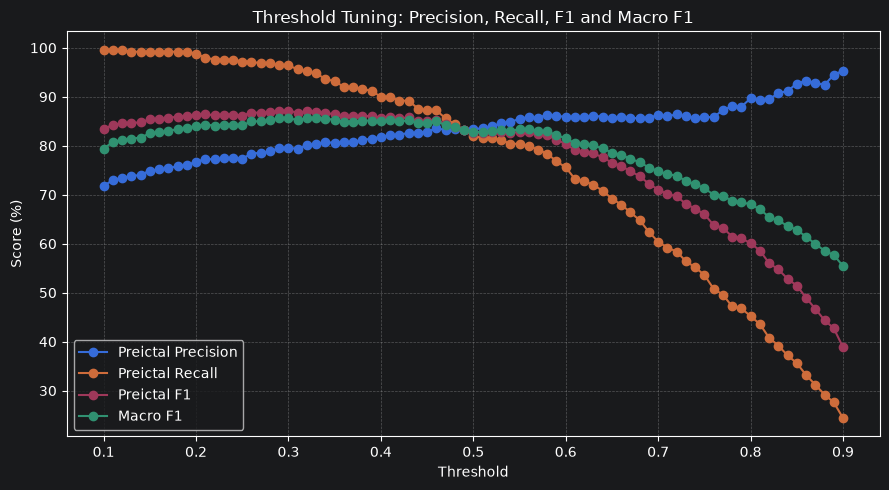

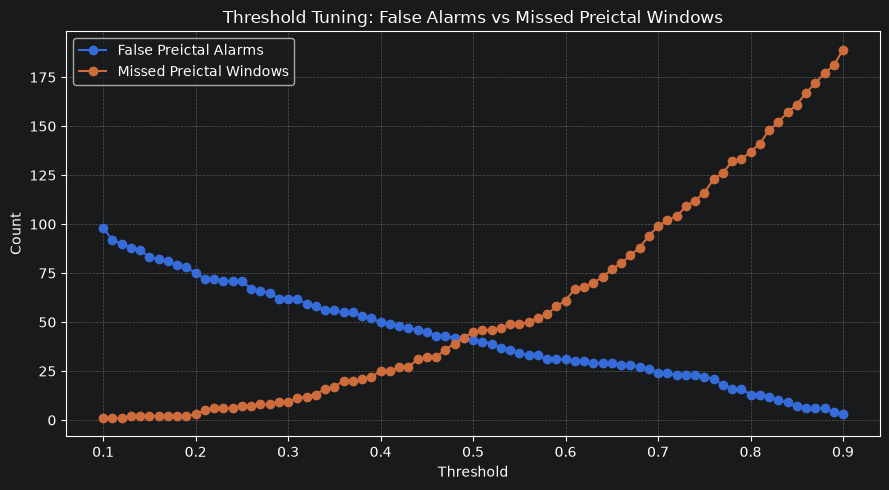


Saved figures:
D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\pptx_style_result_analysis\threshold_tuning_metric_curves.png
D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_debug_NOT_FOR_FINAL_THESIS\pptx_style_result_analysis\threshold_tuning_error_tradeoff.png


In [33]:
# =============================================================================
# FIXED THRESHOLD RESULT DISPLAY CELL
# Shows threshold tuning table properly without Styler object problem
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load saved threshold table if threshold_df is not already available
try:
    threshold_df
except NameError:
    threshold_df = pd.read_csv(FIG_DIR / "threshold_tuning_improvement_table.csv")

# Convert metrics to percentage for easier reading
view_df = threshold_df.copy()

for col in ["Accuracy", "Precision_Preictal", "Recall_Preictal", "F1_Preictal", "Macro_F1"]:
    view_df[col] = view_df[col] * 100

# -------------------------------------------------------------------------
# 1. Best thresholds by Macro F1
# -------------------------------------------------------------------------
top_macro = (
    view_df.sort_values("Macro_F1", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("\nTop 15 thresholds by Macro F1:\n")
print(top_macro.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

display(top_macro)

# -------------------------------------------------------------------------
# 2. Thresholds with Preictal Recall >= 85%, sorted by fewer false alarms
# -------------------------------------------------------------------------
recall_safe = (
    view_df[view_df["Recall_Preictal"] >= 85]
    .sort_values(["False_Alarms_FP", "Macro_F1"], ascending=[True, False])
    .head(15)
    .reset_index(drop=True)
)

print("\nThresholds with Preictal Recall >= 85%, sorted by fewer false alarms:\n")
print(recall_safe.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

display(recall_safe)

# -------------------------------------------------------------------------
# 3. Recommended threshold
# Rule: Recall >= 85%, then choose lowest false alarms, then highest Macro F1
# -------------------------------------------------------------------------
if len(recall_safe) > 0:
    best_row = recall_safe.iloc[0]

    print("\nRecommended Threshold Based on Recall >= 85% and Lower False Alarms:")
    print(f"Threshold              : {best_row['Threshold']:.2f}")
    print(f"Accuracy               : {best_row['Accuracy']:.2f}%")
    print(f"Preictal Precision     : {best_row['Precision_Preictal']:.2f}%")
    print(f"Preictal Recall        : {best_row['Recall_Preictal']:.2f}%")
    print(f"Preictal F1-score      : {best_row['F1_Preictal']:.2f}%")
    print(f"Macro F1-score         : {best_row['Macro_F1']:.2f}%")
    print(f"False Preictal Alarms  : {int(best_row['False_Alarms_FP'])}")
    print(f"Missed Preictal Windows: {int(best_row['Missed_Preictal_FN'])}")

else:
    print("No threshold found with Preictal Recall >= 85%.")

# -------------------------------------------------------------------------
# 4. Plot threshold vs performance metrics
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(view_df["Threshold"], view_df["Precision_Preictal"], marker="o", label="Preictal Precision")
plt.plot(view_df["Threshold"], view_df["Recall_Preictal"], marker="o", label="Preictal Recall")
plt.plot(view_df["Threshold"], view_df["F1_Preictal"], marker="o", label="Preictal F1")
plt.plot(view_df["Threshold"], view_df["Macro_F1"], marker="o", label="Macro F1")
plt.xlabel("Threshold")
plt.ylabel("Score (%)")
plt.title("Threshold Tuning: Precision, Recall, F1 and Macro F1")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_tuning_metric_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# 5. Plot threshold vs false alarms and missed preictal windows
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(view_df["Threshold"], view_df["False_Alarms_FP"], marker="o", label="False Preictal Alarms")
plt.plot(view_df["Threshold"], view_df["Missed_Preictal_FN"], marker="o", label="Missed Preictal Windows")
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.title("Threshold Tuning: False Alarms vs Missed Preictal Windows")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_tuning_error_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved figures:")
print(FIG_DIR / "threshold_tuning_metric_curves.png")
print(FIG_DIR / "threshold_tuning_error_tradeoff.png")

In [36]:
# =============================================================================
# 40-SUBJECT BALANCED DEBUG CONFIG
# Uses 40 valid subjects closest to sub-125
# =============================================================================

cfg = Config(
    data_root=Path(r"D:\SeizeIT2"),
    split_root=Path(r"D:\Multimodal_Seizure_Project"),
    out_root=Path(r"D:\SeizeIT2_Preictal_Turbo_Outputs"),

    # Task setup
    window_sec=10.0,
    stride_sec=10.0,
    target_fs=250,
    preictal_start_min=35.0,
    preictal_end_min=5.0,
    postictal_exclude_min=30.0,
    interictal_margin_min=30.0,

    # Runtime
    device="cuda",
    batch_size=64,
    cpu_threads=12,
    num_workers=0,

    # Prepare/shard settings
    n_jobs=16,
    parallel_shards=True,

    # Training setup
    epochs=35,
    patience=8,
    lr=3e-4,
    weight_decay=1e-4,
    dropout=0.25,
    d_model=96,
    layers=2,
    heads=4,

    # Balanced data, so no extra positive weighting
    pos_weight_cap=1.0,
    force_pos_weight_one=True,
    focal_gamma=0.0,

    # 40-subject balanced debug mode
    tiny_balanced_debug=True,
    debug_pool_all_splits=True,
    debug_row_level_split=True,

    # Select subjects around sub-125
    debug_subject_center=125,
    debug_total_subjects=40,
    debug_max_subjects=40,

    # Larger balanced sample than 12-subject run
    debug_min_available_per_class=7000,
    debug_train_per_class=5000,
    debug_val_per_class=1000,
    debug_test_per_class=1000,

    debug_neg_ratio=1.0,
    debug_use_threshold_tuned_val=True,

    # New folder so old 12-subject result is not overwritten
    model_tag="balanced_near_sub125_40subjects_DEBUG",

    # Keep False in notebook to avoid Triton error
    compile_model=False,

    debug_disable_event_eval=True,

    # Let validation choose threshold
    threshold_mode="balanced",
    save_all_operating_points=True,
)

cfg.make_dirs()
cfg.save()
set_seed(cfg.seed)
used_threads = setup_runtime(cfg)
device = get_device(cfg)

print("=" * 90)
print("SEIZEIT2 PREICTAL PREDICTION - 40 SUBJECT BALANCED DEBUG RUN")
print("=" * 90)
print("WARNING: This is a balanced debug/window-level experiment, not final subject-wise evaluation.")
print("Dataset root :", cfg.data_root)
print("Output root  :", cfg.out_root)
print("Model folder :", cfg.model_dir)
print("Shard index  :", cfg.shard_index_path)
print("Device       :", device)
print("CUDA         :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))
print("Subjects     :", cfg.debug_total_subjects)
print("Train/class  :", cfg.debug_train_per_class)
print("Val/class    :", cfg.debug_val_per_class)
print("Test/class   :", cfg.debug_test_per_class)
print("=" * 90)

SEIZEIT2 PREICTAL PREDICTION - 40 SUBJECT BALANCED DEBUG RUN
Dataset root : D:\SeizeIT2
Output root  : D:\SeizeIT2_Preictal_Turbo_Outputs
Model folder : D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG
Shard index  : D:\SeizeIT2_Preictal_Turbo_Outputs\index\preictal_window_shard_index.csv
Device       : cuda
CUDA         : True
GPU          : NVIDIA GeForce RTX 4080
Subjects     : 40
Train/class  : 5000
Val/class    : 1000
Test/class   : 1000


In [37]:
# =============================================================================
# CHECK WHICH 40 SUBJECTS WILL BE USED
# =============================================================================

if not cfg.shard_index_path.exists():
    print("Shard index missing. Run prepare cell first.")
else:
    shard_index = pd.read_csv(cfg.shard_index_path)

    pool_40 = _select_debug_subject_pool(shard_index, cfg)

    selected_subjects = sorted(
        pool_40["Subject"].unique(),
        key=lambda x: int(str(x).replace("sub-", ""))
    )

    print("Number of selected subjects:", len(selected_subjects))
    print("Selected subjects:")
    print(selected_subjects)

    print("\nAvailable windows in selected 40-subject pool:")
    print(pool_40.groupby("ClassName").size())

    print("\nAvailable windows per subject:")
    display(pool_40.groupby(["Subject", "ClassName"]).size().unstack(fill_value=0))

Tiny balanced debug subjects selected: ['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-099', 'sub-100', 'sub-101', 'sub-102', 'sub-103', 'sub-104', 'sub-105', 'sub-106', 'sub-107', 'sub-108', 'sub-109', 'sub-110', 'sub-111', 'sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125']
Available in selected pool -> Interictal: 681881, Preictal: 30394
Number of selected subjects: 40
Selected subjects:
['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-099', 'sub-100', 'sub-101', 'sub-102', 'sub-103', 'sub-104', 'sub-105', 'sub-106', 'sub-107', 'sub-108', 'sub-109', 'sub-110', 'sub-111', 'sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-1

ClassName,Interictal,Preictal
Subject,,
sub-077,5289,1263
sub-078,23400,180
sub-079,12307,2520
sub-080,13172,1440
sub-083,19189,180
sub-084,15868,362
sub-085,14823,225
sub-086,24142,560
sub-089,30259,802


In [ ]:
# =============================================================================
# PREPARE DATA ONLY IF SHARD INDEX IS MISSING
# =============================================================================

# RUN_PREPARE = False
#
# if RUN_PREPARE or not cfg.shard_index_path.exists():
#     stage_prepare(cfg)
# else:
#     print("Prepare skipped. Existing shard index found:")
#     print(cfg.shard_index_path)
#
#     shard_index = pd.read_csv(cfg.shard_index_path)
#     print("Total shard index rows:", len(shard_index))
#     print(shard_index.groupby(["Split", "ClassName"]).size())

In [38]:
# =============================================================================
# TRAIN 40-SUBJECT BALANCED DEBUG MODEL
# =============================================================================

training_objects = train_with_step_checkpoints(
    cfg,
    checkpoint_every_steps=500,
    resume_from_latest_epoch=False
)

BUILDING TRAINING OBJECTS
Rows: 986783
Split  ClassName 
test   Interictal    432130
       Preictal       21162
train  Interictal    491481
       Preictal       42010
dtype: int64

Device: cuda
CPU threads used by PyTorch: 12
CUDA devices: 1
Primary GPU: NVIDIA GeForce RTX 4080
Primary GPU memory: 15.99 GB
Tiny balanced debug subjects selected: ['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-099', 'sub-100', 'sub-101', 'sub-102', 'sub-103', 'sub-104', 'sub-105', 'sub-106', 'sub-107', 'sub-108', 'sub-109', 'sub-110', 'sub-111', 'sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125']
Available in selected pool -> Interictal: 681881, Preictal: 30394

TINY BALANCED DEBUG SPLIT - NOT FOR FINAL THESIS REPORTING

TRAIN rows: 10000
ClassName
Preictal      5000
Interictal    5000
Name: count, dtyp

train epoch 1: 100%|██████████| 156/156 [04:24<00:00,  1.69s/it, loss=0.5583, step=156]


Epoch 001 | Step 156 | Train loss 0.6566 F1@0.5 0.5731 Recall@0.5 0.5185 | Val loss 0.6065 F1(bestThr) 0.7098 Precision 0.6151 Recall 0.8390 Thr 0.4148 | Val F1@0.5 0.7020
Saved best preictal model: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\best_preictal_cnn_tcn_transformer.pt
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\notebook_checkpoints\checkpoint_epoch_001.pt


train epoch 2: 100%|██████████| 156/156 [00:50<00:00,  3.06it/s, loss=0.4703, step=312]


Epoch 002 | Step 312 | Train loss 0.5786 F1@0.5 0.7075 Recall@0.5 0.7100 | Val loss 0.5830 F1(bestThr) 0.7564 Precision 0.6808 Recall 0.8510 Thr 0.5552 | Val F1@0.5 0.7518
Saved best preictal model: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\best_preictal_cnn_tcn_transformer.pt
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\notebook_checkpoints\checkpoint_epoch_002.pt


...

Epoch 033 | Step 5148 | Train loss 0.0257 F1@0.5 0.9913 Recall@0.5 0.9916 | Val loss 0.6798 F1(bestThr) 0.8834 Precision 0.8693 Recall 0.8980 Thr 0.8525 | Val F1@0.5 0.8800
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\notebook_checkpoints\checkpoint_epoch_033.pt


train epoch 34: 100%|██████████| 156/156 [00:50<00:00,  3.11it/s, loss=0.0235, step=5304]


Epoch 034 | Step 5304 | Train loss 0.0275 F1@0.5 0.9920 Recall@0.5 0.9924 | Val loss 0.6858 F1(bestThr) 0.8849 Precision 0.8638 Recall 0.9070 Thr 0.5566 | Val F1@0.5 0.8833
Saved best preictal model: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\best_preictal_cnn_tcn_transformer.pt
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\notebook_checkpoints\checkpoint_epoch_034.pt


train epoch 35: 100%|██████████| 156/156 [00:49<00:00,  3.13it/s, loss=0.0069, step=5460]


Epoch 035 | Step 5460 | Train loss 0.0251 F1@0.5 0.9914 Recall@0.5 0.9912 | Val loss 0.6711 F1(bestThr) 0.8841 Precision 0.8517 Recall 0.9190 Thr 0.2180 | Val F1@0.5 0.8837
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\notebook_checkpoints\checkpoint_epoch_035.pt

TRAINING FINISHED
Best validation F1: 0.8848780487799881
Best model path: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\best_preictal_cnn_tcn_transformer.pt
Checkpoint folder: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\notebook_checkpoints


In [39]:
# =============================================================================
# FINAL EVALUATION
# =============================================================================

selected_metrics = final_evaluation_from_best_checkpoint(cfg)

print("\nSelected metrics:")
print(selected_metrics)
print("\nResults saved in:")
print(cfg.model_dir)

Tiny balanced debug subjects selected: ['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-099', 'sub-100', 'sub-101', 'sub-102', 'sub-103', 'sub-104', 'sub-105', 'sub-106', 'sub-107', 'sub-108', 'sub-109', 'sub-110', 'sub-111', 'sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125']
Available in selected pool -> Interictal: 681881, Preictal: 30394

TINY BALANCED DEBUG SPLIT - NOT FOR FINAL THESIS REPORTING

TRAIN rows: 10000
ClassName
Preictal      5000
Interictal    5000
Name: count, dtype: int64
Subjects: ['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-099', 'sub-100', 'sub-101', 'sub-102', 'sub-103'] ...

VAL rows: 2000
ClassName
Interictal    1000
Preictal      1000
Na

Selected threshold mode: balanced
Selected threshold: 0.556640625


Evaluation alignment fix active: metrics use pred_df labels after sorting, not raw y_test order.
Skipping event-level alarm summary for tiny sampled debug split; it requires continuous recordings.

WINDOW-LEVEL PREICTAL REPORT [sensitivity | threshold=0.0034]
              precision    recall  f1-score   support

  Interictal       0.98      0.63      0.77      1000
    Preictal       0.73      0.99      0.84      1000

    accuracy                           0.81      2000
   macro avg       0.86      0.81      0.80      2000
weighted avg       0.86      0.81      0.80      2000

Confusion Matrix
[[632 368]
 [ 11 989]]
Metrics
{'model': 'Storage_Efficient_Raw_Multimodal_Preictal_CNN_TCN_Transformer_Optimized', 'task': 'Interictal_vs_Preictal', 'operating_point': 'sensitivity', 'accuracy': 0.8105, 'precision': 0.7288135593220338, 'recall_sensitivity': 0.989, 'f1': 0.8392023759015698, 'auroc': 0.9321204999999999, 'auprc': 0.9155309478619836, 'threshold': 0.0034160614013671875, 'n_test_wi

Result folder: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG
Saving graphs to: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\result_analysis_40_subjects
Loaded prediction file: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\preictal_test_predictions.csv


,Subject,Session,Run,RecordID,WindowID,WindowStart,WindowEnd,Label,ClassName,Split,SecondsToNextSeizure,Prob_Preictal,Prob_Interictal,Prob_Preictal_Smooth,PredictedLabel,PredictedClass,PositiveWindow,PositiveCountConsecutive,AlarmRaw,Alarm
0,sub-077,ses-01,run-02,sub-077_ses-01_run-02,1216,12160.0,12170.0,1,Preictal,test,1471.0,0.999512,0.000488,0.999512,1,Preictal,1,1.0,0,0
1,sub-077,ses-01,run-02,sub-077_ses-01_run-02,1238,12380.0,12390.0,1,Preictal,test,1251.0,0.997559,0.002441,0.998535,1,Preictal,1,2.0,0,0
2,sub-077,ses-01,run-02,sub-077_ses-01_run-02,1271,12710.0,12720.0,1,Preictal,test,921.0,0.997070,0.002930,0.998047,1,Preictal,1,3.0,1,1
3,sub-077,ses-01,run-02,sub-077_ses-01_run-02,1660,16600.0,16610.0,1,Preictal,test,1983.0,0.999512,0.000488,0.998047,1,Preictal,1,3.0,1,1
4,sub-077,ses-01,run-02,sub-077_ses-01_run-02,1691,16910.0,16920.0,1,Preictal,test,1673.0,0.999023,0.000977,0.998535,1,Preictal,1,3.0,1,0


Selected threshold: 0.556640625
Threshold mode: balanced

Per-class classification matrix


,Class,Precision,Recall,F1-score
0,Interictal (0),88.07%,83.40%,85.67%
1,Preictal (1),84.24%,88.70%,86.41%



Overall model performance


,Metric,Value
0,Subjects Used,40
1,Selected Threshold,0.5566
2,Threshold Mode,balanced
3,Accuracy,86.05%
4,Macro Precision,86.15%
5,Macro Recall,86.05%
6,Macro F1-score,86.04%
7,Weighted F1-score,86.04%
8,Preictal Precision,84.24%
9,Preictal Recall,88.70%


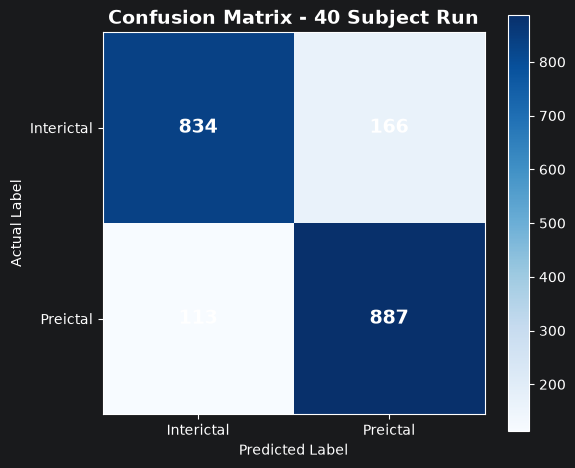

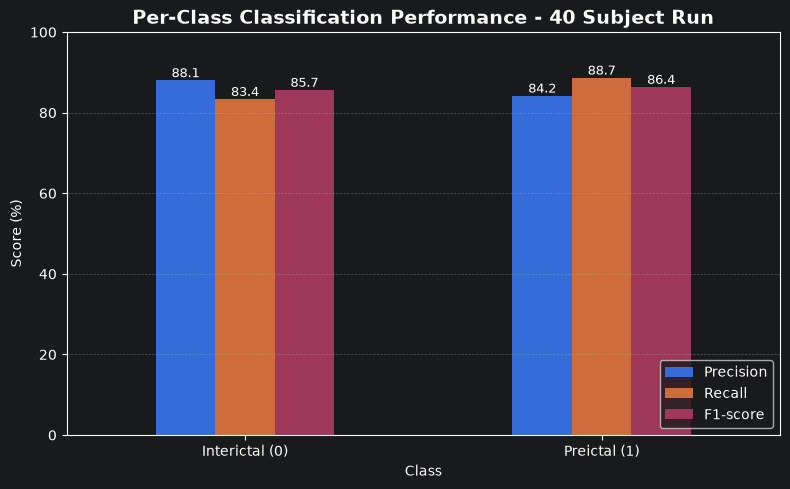

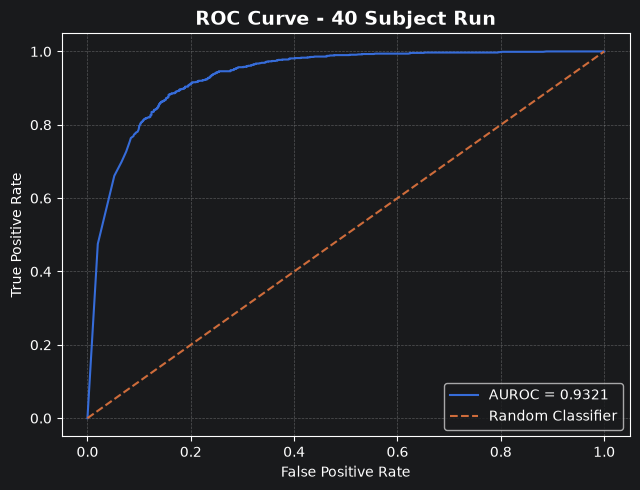

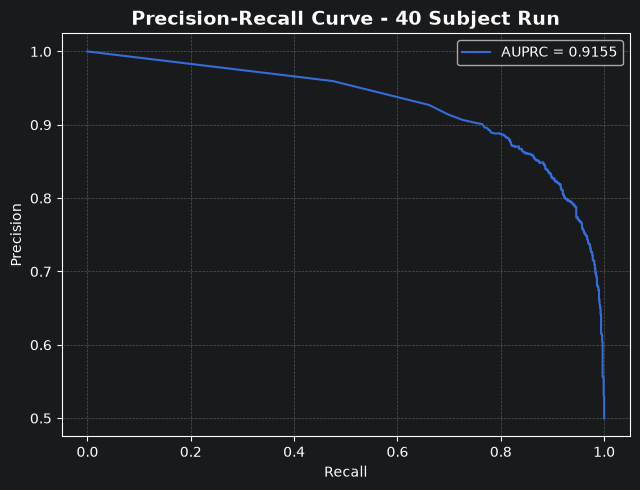

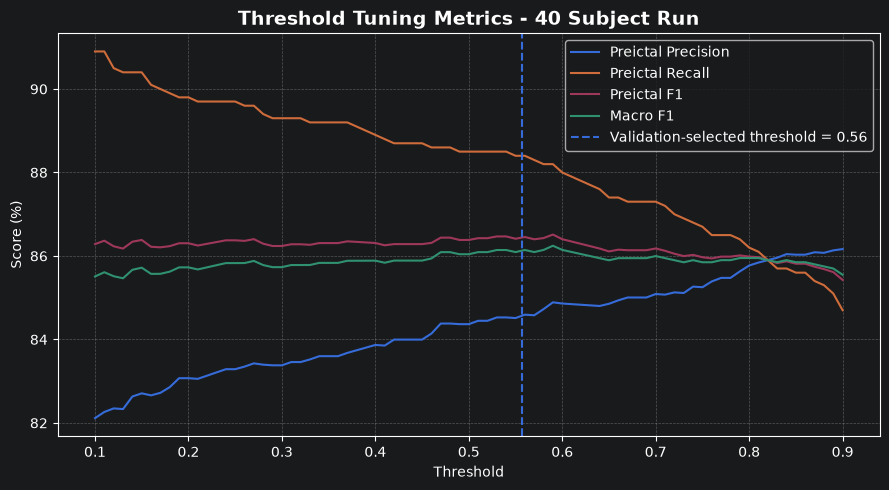

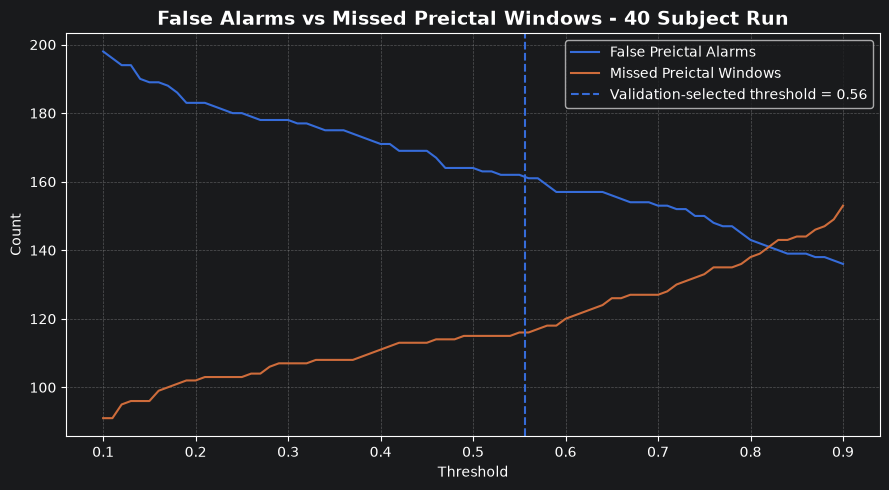


Training history loaded:


,Epoch,GlobalStep,TrainLoss,TrainF1,TrainRecall,ValLoss,ValF1,ValRecall,ValPrecision,ValThreshold,ValF1_at_0_5,ValRecall_at_0_5,LR
0,1,156,0.656581,0.573137,0.518533,0.606505,0.709814,0.839,0.615103,0.414795,0.701955,0.736,0.000081
1,2,312,0.578560,0.707514,0.709994,0.583023,0.756444,0.851,0.680800,0.555176,0.751803,0.886,0.000195
2,3,468,0.526519,0.750149,0.753905,0.522260,0.765845,0.870,0.683962,0.411377,0.754419,0.811,0.000287
3,4,624,0.498544,0.764142,0.782051,0.469876,0.783163,0.921,0.681213,0.394775,0.778487,0.854,0.000300
4,5,780,0.451559,0.789889,0.802246,0.421268,0.817981,0.928,0.731284,0.408691,0.814645,0.890,0.000298


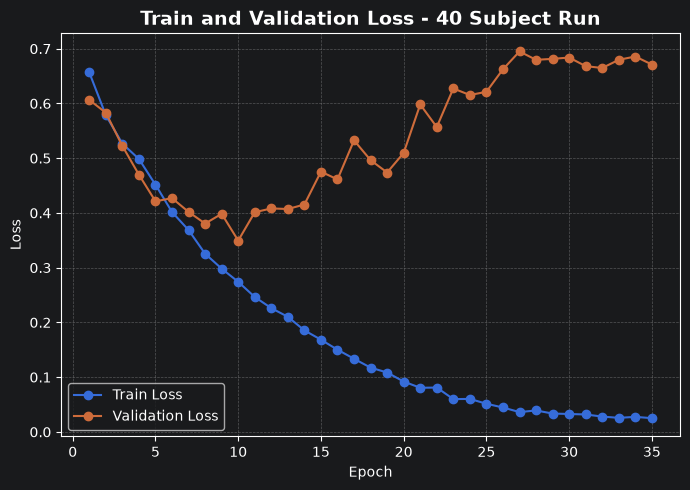

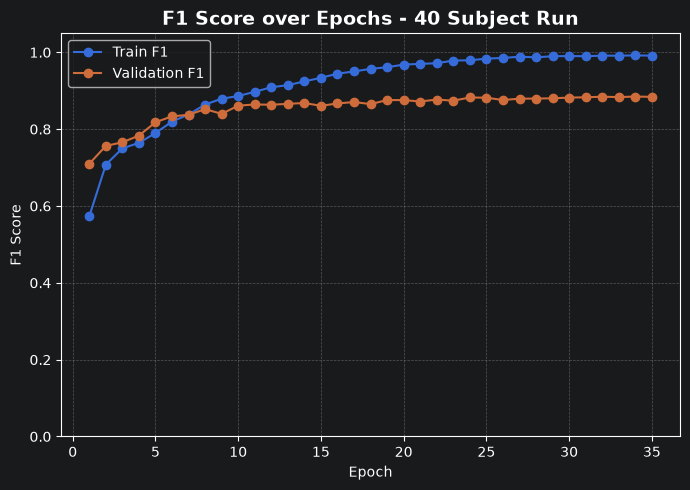

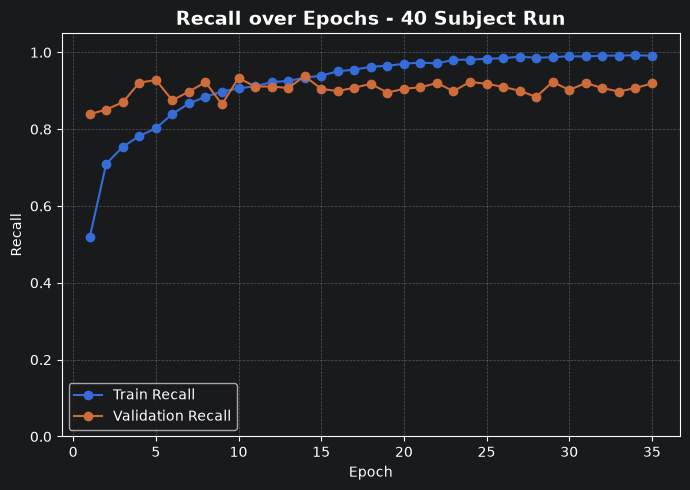


### 40-Subject Result Summary

The 40-subject balanced debug experiment achieved:

- **Accuracy:** 86.05%
- **Macro F1-score:** 86.04%
- **Preictal Precision:** 84.24%
- **Preictal Recall:** 88.70%
- **Preictal F1-score:** 86.41%
- **AUROC:** 0.9321
- **AUPRC:** 0.9155
- **Correct Interictal:** 834
- **False Preictal Alarms:** 166
- **Missed Preictal Windows:** 113
- **Correct Preictal:** 887

Result files saved in:

`D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\result_analysis_40_subjects`


Done. All result-analysis graphs saved to:
D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\result_analysis_40_subjects


In [40]:
# =============================================================================
#  RESULT ANALYSIS GRAPHS
# =============================================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

RESULT_DIR = Path(cfg.model_dir)
FIG_DIR = RESULT_DIR / "result_analysis_40_subjects"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Result folder:", RESULT_DIR)
print("Saving graphs to:", FIG_DIR)

# -----------------------------------------------------------------------------
# Load final selected prediction file
# -----------------------------------------------------------------------------
pred_path = RESULT_DIR / "preictal_test_predictions.csv"

if not pred_path.exists():
    possible = sorted(RESULT_DIR.glob("preictal_test_predictions_*.csv"))
    if len(possible) == 0:
        raise FileNotFoundError("No prediction CSV found. Run final_evaluation_from_best_checkpoint(cfg) first.")
    pred_path = possible[0]

pred_df = pd.read_csv(pred_path)

print("Loaded prediction file:", pred_path)
display(pred_df.head())

# -----------------------------------------------------------------------------
# Use validation-selected threshold from prediction file
# -----------------------------------------------------------------------------
y_true = pred_df["Label"].astype(int).values

if "PredictedLabel" in pred_df.columns:
    y_pred = pred_df["PredictedLabel"].astype(int).values
else:
    raise ValueError("PredictedLabel column not found.")

if "Prob_Preictal" in pred_df.columns:
    y_prob = pred_df["Prob_Preictal"].astype(float).values
else:
    raise ValueError("Prob_Preictal column not found.")

# Get threshold
threshold_path = RESULT_DIR / "preictal_threshold.json"
if threshold_path.exists():
    with open(threshold_path, "r", encoding="utf-8") as f:
        threshold_info = json.load(f)
    selected_threshold = float(threshold_info.get("best_threshold", np.nan))
    threshold_mode = threshold_info.get("threshold_mode", "unknown")
else:
    selected_threshold = np.nan
    threshold_mode = "unknown"

print("Selected threshold:", selected_threshold)
print("Threshold mode:", threshold_mode)

CLASS_NAMES = ["Interictal (0)", "Preictal (1)"]
CLASS_TICKS = ["Interictal", "Preictal"]

# -----------------------------------------------------------------------------
# Metrics
# -----------------------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

preictal_precision = precision_score(y_true, y_pred, zero_division=0)
preictal_recall = recall_score(y_true, y_pred, zero_division=0)
preictal_f1 = f1_score(y_true, y_pred, zero_division=0)

auroc = roc_auc_score(y_true, y_prob)
auprc = average_precision_score(y_true, y_prob)

# -----------------------------------------------------------------------------
# Per-class table
# -----------------------------------------------------------------------------
report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame([
    {
        "Class": "Interictal (0)",
        "Precision": report_dict["Interictal (0)"]["precision"] * 100,
        "Recall": report_dict["Interictal (0)"]["recall"] * 100,
        "F1-score": report_dict["Interictal (0)"]["f1-score"] * 100
    },
    {
        "Class": "Preictal (1)",
        "Precision": report_dict["Preictal (1)"]["precision"] * 100,
        "Recall": report_dict["Preictal (1)"]["recall"] * 100,
        "F1-score": report_dict["Preictal (1)"]["f1-score"] * 100
    }
])

print("\nPer-class classification matrix")
display(per_class_df.style.format({
    "Precision": "{:.2f}%",
    "Recall": "{:.2f}%",
    "F1-score": "{:.2f}%"
}))

per_class_df.to_csv(FIG_DIR / "per_class_classification_matrix_40_subjects.csv", index=False)

# -----------------------------------------------------------------------------
# Overall metrics table
# -----------------------------------------------------------------------------
overall_df = pd.DataFrame([
    {"Metric": "Subjects Used", "Value": "40"},
    {"Metric": "Selected Threshold", "Value": f"{selected_threshold:.4f}"},
    {"Metric": "Threshold Mode", "Value": threshold_mode},
    {"Metric": "Accuracy", "Value": f"{accuracy * 100:.2f}%"},
    {"Metric": "Macro Precision", "Value": f"{macro_precision * 100:.2f}%"},
    {"Metric": "Macro Recall", "Value": f"{macro_recall * 100:.2f}%"},
    {"Metric": "Macro F1-score", "Value": f"{macro_f1 * 100:.2f}%"},
    {"Metric": "Weighted F1-score", "Value": f"{weighted_f1 * 100:.2f}%"},
    {"Metric": "Preictal Precision", "Value": f"{preictal_precision * 100:.2f}%"},
    {"Metric": "Preictal Recall", "Value": f"{preictal_recall * 100:.2f}%"},
    {"Metric": "Preictal F1-score", "Value": f"{preictal_f1 * 100:.2f}%"},
    {"Metric": "AUROC", "Value": f"{auroc:.4f}"},
    {"Metric": "AUPRC", "Value": f"{auprc:.4f}"},
    {"Metric": "Correct Interictal", "Value": int(tn)},
    {"Metric": "False Preictal Alarms", "Value": int(fp)},
    {"Metric": "Missed Preictal Windows", "Value": int(fn)},
    {"Metric": "Correct Preictal", "Value": int(tp)}
])

print("\nOverall model performance")
display(overall_df)
overall_df.to_csv(FIG_DIR / "overall_metrics_40_subjects.csv", index=False)

# -----------------------------------------------------------------------------
# Confusion matrix
# -----------------------------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - 40 Subject Run", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], CLASS_TICKS)
plt.yticks([0, 1], CLASS_TICKS)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14, fontweight="bold")

plt.colorbar()
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_40_subjects.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# Per-class precision/recall/F1 bar chart
# -----------------------------------------------------------------------------
plot_df = per_class_df.set_index("Class")[["Precision", "Recall", "F1-score"]]

ax = plot_df.plot(kind="bar", figsize=(8, 5), rot=0)
plt.title("Per-Class Classification Performance - 40 Subject Run", fontsize=14, fontweight="bold")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "per_class_precision_recall_f1_40_subjects.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# ROC curve
# -----------------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6.5, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve - 40 Subject Run", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curve_40_subjects.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# Precision-Recall curve
# -----------------------------------------------------------------------------
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6.5, 5))
plt.plot(recall_curve, precision_curve, label=f"AUPRC = {auprc:.4f}")
plt.title("Precision-Recall Curve - 40 Subject Run", fontsize=14, fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "precision_recall_curve_40_subjects.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# Threshold tuning on test probabilities for analysis only
# Do not claim this threshold was selected before testing.
# -----------------------------------------------------------------------------
threshold_rows = []
thresholds = np.arange(0.10, 0.91, 0.01)

for th in thresholds:
    temp_pred = (y_prob >= th).astype(int)
    temp_cm = confusion_matrix(y_true, temp_pred, labels=[0, 1])
    temp_tn, temp_fp, temp_fn, temp_tp = temp_cm.ravel()

    threshold_rows.append({
        "Threshold": round(th, 2),
        "Accuracy": accuracy_score(y_true, temp_pred) * 100,
        "Preictal Precision": precision_score(y_true, temp_pred, zero_division=0) * 100,
        "Preictal Recall": recall_score(y_true, temp_pred, zero_division=0) * 100,
        "Preictal F1": f1_score(y_true, temp_pred, zero_division=0) * 100,
        "Macro F1": f1_score(y_true, temp_pred, average="macro", zero_division=0) * 100,
        "False Alarms": temp_fp,
        "Missed Preictal": temp_fn
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(FIG_DIR / "threshold_tuning_table_40_subjects.csv", index=False)

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Preictal Precision"], label="Preictal Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Preictal Recall"], label="Preictal Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Preictal F1"], label="Preictal F1")
plt.plot(threshold_df["Threshold"], threshold_df["Macro F1"], label="Macro F1")

if not np.isnan(selected_threshold):
    plt.axvline(selected_threshold, linestyle="--", label=f"Validation-selected threshold = {selected_threshold:.2f}")

plt.title("Threshold Tuning Metrics - 40 Subject Run", fontsize=14, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Score (%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_tuning_metrics_40_subjects.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["False Alarms"], label="False Preictal Alarms")
plt.plot(threshold_df["Threshold"], threshold_df["Missed Preictal"], label="Missed Preictal Windows")

if not np.isnan(selected_threshold):
    plt.axvline(selected_threshold, linestyle="--", label=f"Validation-selected threshold = {selected_threshold:.2f}")

plt.title("False Alarms vs Missed Preictal Windows - 40 Subject Run", fontsize=14, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_error_tradeoff_40_subjects.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# Training curves
# -----------------------------------------------------------------------------
history_path = RESULT_DIR / "preictal_training_history_notebook.csv"

if history_path.exists():
    history_df = pd.read_csv(history_path)

    print("\nTraining history loaded:")
    display(history_df.head())

    # Loss curve
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["Epoch"], history_df["TrainLoss"], marker="o", label="Train Loss")
    plt.plot(history_df["Epoch"], history_df["ValLoss"], marker="o", label="Validation Loss")
    plt.title("Train and Validation Loss - 40 Subject Run", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "train_validation_loss_40_subjects.png", dpi=300, bbox_inches="tight")
    plt.show()

    # F1 curve
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["Epoch"], history_df["TrainF1"], marker="o", label="Train F1")
    plt.plot(history_df["Epoch"], history_df["ValF1"], marker="o", label="Validation F1")
    plt.title("F1 Score over Epochs - 40 Subject Run", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "f1_over_epochs_40_subjects.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Recall curve
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["Epoch"], history_df["TrainRecall"], marker="o", label="Train Recall")
    plt.plot(history_df["Epoch"], history_df["ValRecall"], marker="o", label="Validation Recall")
    plt.title("Recall over Epochs - 40 Subject Run", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "recall_over_epochs_40_subjects.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Training history file not found:", history_path)

# -----------------------------------------------------------------------------
# Final summary
# -----------------------------------------------------------------------------
display(Markdown(f"""
### 40-Subject Result Summary

The 40-subject balanced debug experiment achieved:

- **Accuracy:** {accuracy * 100:.2f}%
- **Macro F1-score:** {macro_f1 * 100:.2f}%
- **Preictal Precision:** {preictal_precision * 100:.2f}%
- **Preictal Recall:** {preictal_recall * 100:.2f}%
- **Preictal F1-score:** {preictal_f1 * 100:.2f}%
- **AUROC:** {auroc:.4f}
- **AUPRC:** {auprc:.4f}
- **Correct Interictal:** {tn}
- **False Preictal Alarms:** {fp}
- **Missed Preictal Windows:** {fn}
- **Correct Preictal:** {tp}

Result files saved in:

`{FIG_DIR}`
"""))

print("Done. All result-analysis graphs saved to:")
print(FIG_DIR)

MULTIMODAL MODEL FOLDER
D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG
STARTING EEG-ONLY ABLATION EXPERIMENT
Only EEG channels are used.
ECG, EMG, and movement channels are masked to zero.
EEG-only output folder: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG_EEG_ONLY_ABLATION
BUILDING TRAINING OBJECTS
Rows: 986783
Split  ClassName 
test   Interictal    432130
       Preictal       21162
train  Interictal    491481
       Preictal       42010
dtype: int64

Device: cuda
CPU threads used by PyTorch: 12
CUDA devices: 1
Primary GPU: NVIDIA GeForce RTX 4080
Primary GPU memory: 15.99 GB
Tiny balanced debug subjects selected: ['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-099', 'sub-100', 'sub-101', 'sub-102', 'sub-103', 'sub-104', 'sub-105', 'sub-1

train epoch 1: 100%|██████████| 156/156 [02:33<00:00,  1.02it/s, loss=0.6884, step=156]


Epoch 001 | Step 156 | Train loss 0.6915 F1@0.5 0.2791 Recall@0.5 0.1877 | Val loss 0.6917 F1(bestThr) 0.6671 Precision 0.5013 Recall 0.9970 Thr 0.4836 | Val F1@0.5 0.2508
Saved best preictal model: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG_EEG_ONLY_ABLATION\best_preictal_cnn_tcn_transformer.pt
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG_EEG_ONLY_ABLATION\notebook_checkpoints\checkpoint_epoch_001.pt


train epoch 2: 100%|██████████| 156/156 [00:50<00:00,  3.08it/s, loss=0.6705, step=312]


Epoch 002 | Step 312 | Train loss 0.6896 F1@0.5 0.4047 Recall@0.5 0.3271 | Val loss 0.6936 F1(bestThr) 0.6667 Precision 0.5000 Recall 1.0000 Thr 0.4709 | Val F1@0.5 0.2938
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG_EEG_ONLY_ABLATION\notebook_checkpoints\checkpoint_epoch_002.pt


...

Epoch 011 | Step 1716 | Train loss 0.6910 F1@0.5 0.5142 Recall@0.5 0.5150 | Val loss 0.6930 F1(bestThr) 0.6667 Precision 0.5000 Recall 1.0000 Thr 0.4419 | Val F1@0.5 0.1107
Saved epoch checkpoint: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG_EEG_ONLY_ABLATION\notebook_checkpoints\checkpoint_epoch_011.pt
Early stopping.

TRAINING FINISHED
Best validation F1: 0.672334396032132
Best model path: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG_EEG_ONLY_ABLATION\best_preictal_cnn_tcn_transformer.pt
Checkpoint folder: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG_EEG_ONLY_ABLATION\notebook_checkpoints
Tiny balanced debug subjects selected: ['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-

Selected threshold mode: balanced
Selected threshold: 0.485107421875


Evaluation alignment fix active: metrics use pred_df labels after sorting, not raw y_test order.
Skipping event-level alarm summary for tiny sampled debug split; it requires continuous recordings.

WINDOW-LEVEL PREICTAL REPORT [sensitivity | threshold=0.4851]
              precision    recall  f1-score   support

  Interictal       1.00      0.01      0.01      1000
    Preictal       0.50      1.00      0.67      1000

    accuracy                           0.50      2000
   macro avg       0.75      0.50      0.34      2000
weighted avg       0.75      0.50      0.34      2000

Confusion Matrix
[[   5  995]
 [   0 1000]]
Metrics
{'model': 'Storage_Efficient_Raw_Multimodal_Preictal_CNN_TCN_Transformer_Optimized', 'task': 'Interictal_vs_Preictal', 'operating_point': 'sensitivity', 'accuracy': 0.5025, 'precision': 0.5012531328320802, 'recall_sensitivity': 1.0, 'f1': 0.667779632721202, 'auroc': 0.5706819999999999, 'auprc': 0.5684153422721281, 'threshold': 0.485107421875, 'n_test_windows'

,Model Input,Accuracy,Macro F1,Preictal Precision,Preictal Recall,Preictal F1,AUROC,AUPRC,False Preictal Alarms,Missed Preictal,Correct Preictal,Threshold,Test Windows
0,EEG-only,0.5025,0.3389,0.5013,1.0000,0.6678,0.5707,0.5684,995,0,1000,0.4851,2000
1,Multimodal: EEG + ECG + EMG + Movement,0.8605,0.8604,0.8424,0.8870,0.8641,0.9321,0.9155,166,113,887,0.5566,2000



Comparison saved to:
D:\SeizeIT2_Preictal_Turbo_Outputs\eeg_only_vs_multimodal_analysis\eeg_only_vs_multimodal_comparison.csv


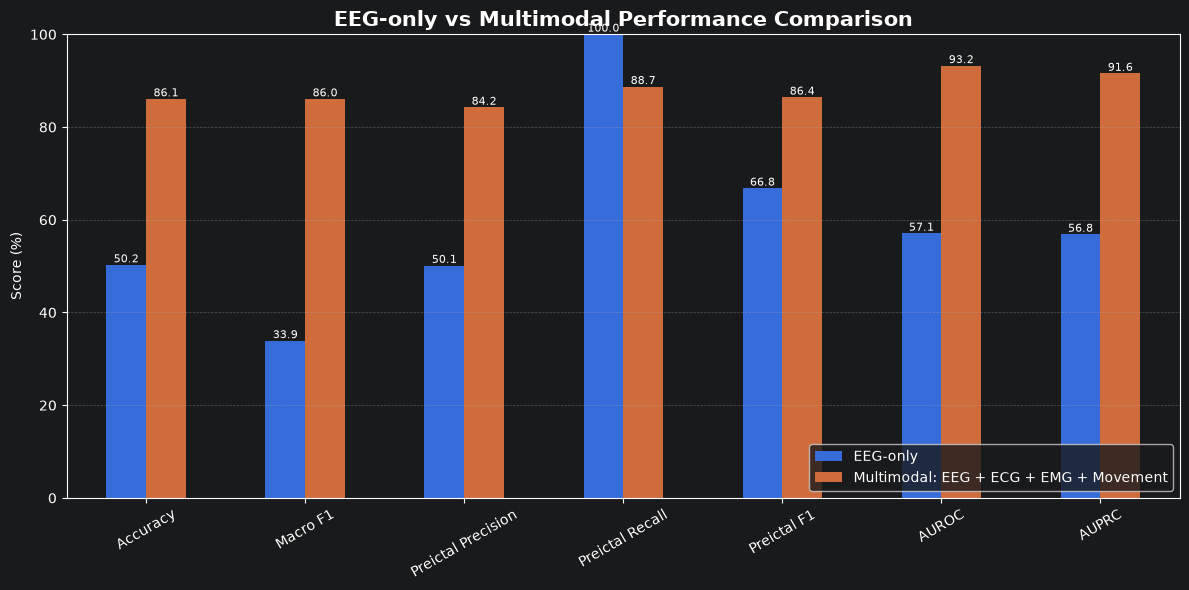

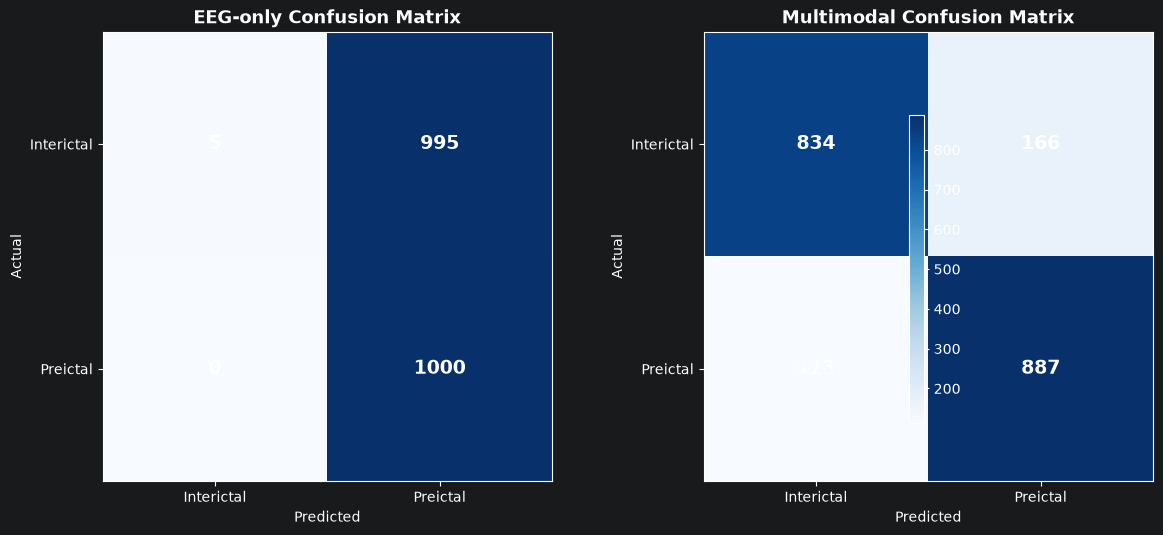


## EEG-only vs Multimodal Interpretation

**EEG-only Preictal F1:** 0.6678  
**Multimodal Preictal F1:** 0.8641  

**EEG-only Preictal Recall:** 1.0000  
**Multimodal Preictal Recall:** 0.8870  

**EEG-only AUPRC:** 0.5684  
**Multimodal AUPRC:** 0.9155  

**Conclusion:**  
The multimodal model achieved higher Preictal F1-score than the EEG-only model. This supports the use of ECG, EMG, and movement signals together with EEG for preictal prediction.

All comparison files are saved in:

`D:\SeizeIT2_Preictal_Turbo_Outputs\eeg_only_vs_multimodal_analysis`


In [42]:
# =============================================================================
# EEG-ONLY ABLATION + MULTIMODAL COMPARISON
# Purpose:
# Test whether EEG-only performs better/worse than full multimodal input.
# This keeps EEG channels and masks ECG, EMG, and Movement channels.
# Run this after your multimodal model has already been trained/evaluated.
# =============================================================================

import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# -----------------------------------------------------------------------------
# 1. Save multimodal config/model folder before changing anything
# -----------------------------------------------------------------------------
cfg_multi = copy.deepcopy(cfg)
MULTIMODAL_DIR = Path(cfg_multi.model_dir)

print("=" * 90)
print("MULTIMODAL MODEL FOLDER")
print(MULTIMODAL_DIR)
print("=" * 90)

# -----------------------------------------------------------------------------
# 2. Create EEG-only dataset class by masking ECG, EMG, and MOV channels
# -----------------------------------------------------------------------------
OriginalShardWindowDataset = ShardWindowDataset

class EEGOnlyShardWindowDataset(OriginalShardWindowDataset):
    def __getitem__(self, idx):
        x, y = super().__getitem__(idx)

        # Expected channel layout from your pipeline:
        # EEG = channels 0-1
        # ECG = channel 2
        # EMG = channel 3
        # MOV = channels 4-9
        #
        # Keep EEG only, mask all other modalities.
        x[2:, :] = 0.0

        return x, y

# Replace dataset class globally so make_loaders() uses EEG-only windows
ShardWindowDataset = EEGOnlyShardWindowDataset

# -----------------------------------------------------------------------------
# 3. Create EEG-only config using same settings and same split logic
# -----------------------------------------------------------------------------
cfg_eeg = copy.deepcopy(cfg_multi)

# Save EEG-only results in a separate folder
cfg_eeg.model_tag = cfg_multi.model_tag + "_EEG_ONLY_ABLATION"

# Keep same seed for same balanced split
cfg_eeg.seed = cfg_multi.seed

# Optional: reduce epochs if time is short
# For fairer comparison, keep same epochs.
# If needed, uncomment the next line:
# cfg_eeg.epochs = min(cfg_eeg.epochs, 20)

cfg_eeg.make_dirs()
cfg_eeg.save()
set_seed(cfg_eeg.seed)

print("=" * 90)
print("STARTING EEG-ONLY ABLATION EXPERIMENT")
print("=" * 90)
print("Only EEG channels are used.")
print("ECG, EMG, and movement channels are masked to zero.")
print("EEG-only output folder:", cfg_eeg.model_dir)
print("=" * 90)

# -----------------------------------------------------------------------------
# 4. Train EEG-only model
# -----------------------------------------------------------------------------
training_objects_eeg = train_with_step_checkpoints(
    cfg_eeg,
    checkpoint_every_steps=500,
    resume_from_latest_epoch=False
)

# -----------------------------------------------------------------------------
# 5. Final evaluation for EEG-only model
# -----------------------------------------------------------------------------
selected_metrics_eeg = final_evaluation_from_best_checkpoint(cfg_eeg)

print("\nEEG-only selected metrics:")
print(selected_metrics_eeg)

# Restore original dataset class for safety
ShardWindowDataset = OriginalShardWindowDataset

# -----------------------------------------------------------------------------
# 6. Helper function to load predictions and calculate metrics
# -----------------------------------------------------------------------------
def find_prediction_file(model_dir):
    model_dir = Path(model_dir)

    candidates = [
        model_dir / "preictal_test_predictions.csv",
        model_dir / "test_predictions.csv",
        model_dir / "preictal_test_predictions_balanced.csv"
    ]

    for p in candidates:
        if p.exists():
            return p

    possible = sorted(model_dir.glob("*prediction*.csv")) + sorted(model_dir.glob("*predictions*.csv"))
    if len(possible) > 0:
        return possible[0]

    raise FileNotFoundError(f"No prediction CSV found inside {model_dir}")


def get_threshold_info(model_dir):
    model_dir = Path(model_dir)

    candidates = [
        model_dir / "preictal_threshold.json",
        model_dir / "threshold.json",
        model_dir / "binary_thresholds.json"
    ]

    for p in candidates:
        if p.exists():
            try:
                with open(p, "r", encoding="utf-8") as f:
                    data = json.load(f)

                for key in ["best_threshold", "threshold", "selected_threshold", "preictal_threshold"]:
                    if key in data:
                        return float(data[key])

            except Exception:
                pass

    return np.nan


def calculate_result_from_predictions(model_name, model_dir):
    pred_path = find_prediction_file(model_dir)
    df = pd.read_csv(pred_path)

    if "Label" not in df.columns:
        raise ValueError(f"Label column not found in {pred_path}")

    # Probability column
    if "Prob_Preictal" in df.columns:
        prob_col = "Prob_Preictal"
    elif "Prob_Preictal_Smooth" in df.columns:
        prob_col = "Prob_Preictal_Smooth"
    else:
        raise ValueError(f"No preictal probability column found in {pred_path}")

    y_true = df["Label"].astype(int).values
    y_prob = df[prob_col].astype(float).values

    # Prediction column
    if "PredictedLabel" in df.columns:
        y_pred = df["PredictedLabel"].astype(int).values
    elif "Predicted" in df.columns:
        y_pred = df["Predicted"].astype(int).values
    else:
        # If prediction column missing, use saved threshold
        th = get_threshold_info(model_dir)
        if np.isnan(th):
            th = 0.5
        y_pred = (y_prob >= th).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    threshold = get_threshold_info(model_dir)

    result = {
        "Model Input": model_name,
        "Prediction File": str(pred_path),
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Preictal Precision": precision_score(y_true, y_pred, zero_division=0),
        "Preictal Recall": recall_score(y_true, y_pred, zero_division=0),
        "Preictal F1": f1_score(y_true, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y_true, y_prob),
        "AUPRC": average_precision_score(y_true, y_prob),
        "Correct Interictal": int(tn),
        "False Preictal Alarms": int(fp),
        "Missed Preictal": int(fn),
        "Correct Preictal": int(tp),
        "Test Windows": int(len(y_true))
    }

    return result, cm, df


# -----------------------------------------------------------------------------
# 7. Load multimodal and EEG-only results
# -----------------------------------------------------------------------------
multi_result, multi_cm, multi_df = calculate_result_from_predictions(
    "Multimodal: EEG + ECG + EMG + Movement",
    MULTIMODAL_DIR
)

eeg_result, eeg_cm, eeg_df = calculate_result_from_predictions(
    "EEG-only",
    cfg_eeg.model_dir
)

comparison_df = pd.DataFrame([eeg_result, multi_result])

# Reorder columns for clean display
display_cols = [
    "Model Input",
    "Accuracy",
    "Macro F1",
    "Preictal Precision",
    "Preictal Recall",
    "Preictal F1",
    "AUROC",
    "AUPRC",
    "False Preictal Alarms",
    "Missed Preictal",
    "Correct Preictal",
    "Threshold",
    "Test Windows"
]

comparison_display = comparison_df[display_cols].copy()

print("\nEEG-only vs Multimodal Comparison")
display(comparison_display.style.format({
    "Accuracy": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Preictal Precision": "{:.4f}",
    "Preictal Recall": "{:.4f}",
    "Preictal F1": "{:.4f}",
    "AUROC": "{:.4f}",
    "AUPRC": "{:.4f}",
    "Threshold": "{:.4f}"
}))

# -----------------------------------------------------------------------------
# 8. Save comparison result
# -----------------------------------------------------------------------------
COMPARE_DIR = Path(cfg_multi.out_root) / "eeg_only_vs_multimodal_analysis"
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

comparison_csv = COMPARE_DIR / "eeg_only_vs_multimodal_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

print("\nComparison saved to:")
print(comparison_csv)

# -----------------------------------------------------------------------------
# 9. Plot comparison bar chart
# -----------------------------------------------------------------------------
plot_metrics = [
    "Accuracy",
    "Macro F1",
    "Preictal Precision",
    "Preictal Recall",
    "Preictal F1",
    "AUROC",
    "AUPRC"
]

plot_df = comparison_df.set_index("Model Input")[plot_metrics].T * 100

ax = plot_df.plot(kind="bar", figsize=(12, 6), rot=30)
plt.title("EEG-only vs Multimodal Performance Comparison", fontsize=15, fontweight="bold")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8)

plt.tight_layout()
plt.savefig(COMPARE_DIR / "eeg_only_vs_multimodal_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# 10. Confusion matrix comparison
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cms = [eeg_cm, multi_cm]
titles = ["EEG-only Confusion Matrix", "Multimodal Confusion Matrix"]
class_names = ["Interictal", "Preictal"]

for ax, cm, title in zip(axes, cms, titles):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold"
            )

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.savefig(COMPARE_DIR / "eeg_only_vs_multimodal_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# 11. Automatic interpretation
# -----------------------------------------------------------------------------
eeg_f1 = eeg_result["Preictal F1"]
multi_f1 = multi_result["Preictal F1"]

eeg_recall = eeg_result["Preictal Recall"]
multi_recall = multi_result["Preictal Recall"]

eeg_auprc = eeg_result["AUPRC"]
multi_auprc = multi_result["AUPRC"]

if multi_f1 > eeg_f1:
    conclusion = (
        "The multimodal model achieved higher Preictal F1-score than the EEG-only model. "
        "This supports the use of ECG, EMG, and movement signals together with EEG for preictal prediction."
    )
elif multi_f1 < eeg_f1:
    conclusion = (
        "The EEG-only model achieved higher Preictal F1-score in this experiment. "
        "This suggests EEG remains highly informative, while multimodal fusion may need further optimization."
    )
else:
    conclusion = (
        "Both EEG-only and multimodal models achieved similar Preictal F1-score. "
        "This indicates EEG is highly informative, while additional modalities may still help in robustness and false-alarm control."
    )

display(Markdown(f"""
## EEG-only vs Multimodal Interpretation

**EEG-only Preictal F1:** {eeg_f1:.4f}
**Multimodal Preictal F1:** {multi_f1:.4f}

**EEG-only Preictal Recall:** {eeg_recall:.4f}
**Multimodal Preictal Recall:** {multi_recall:.4f}

**EEG-only AUPRC:** {eeg_auprc:.4f}
**Multimodal AUPRC:** {multi_auprc:.4f}

**Conclusion:**
{conclusion}

All comparison files are saved in:

`{COMPARE_DIR}`
"""))


# Final Evaluation at Fixed Threshold = 0.56

This section generates the final report metrics. The threshold is not optimized on the test set. 
It is fixed as the validation-selected threshold for the 40-subject experiment.


In [ ]:

# =============================================================================
# FINAL REPORT METRICS (THRESHOLD = 0.56)
# =============================================================================

FINAL_THRESHOLD = 0.56

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    matthews_corrcoef, confusion_matrix
)

y_pred_final = (y_prob >= FINAL_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred_final).ravel()

metrics_summary = {
    "threshold": FINAL_THRESHOLD,
    "accuracy": accuracy_score(y_true, y_pred_final),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred_final),
    "macro_precision": precision_score(y_true, y_pred_final, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred_final, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred_final, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred_final, average="weighted", zero_division=0),
    "interictal_precision": precision_score(y_true, y_pred_final, pos_label=0, zero_division=0),
    "interictal_recall_specificity": recall_score(y_true, y_pred_final, pos_label=0, zero_division=0),
    "interictal_f1": f1_score(y_true, y_pred_final, pos_label=0, zero_division=0),
    "preictal_precision": precision_score(y_true, y_pred_final, pos_label=1, zero_division=0),
    "preictal_recall": recall_score(y_true, y_pred_final, pos_label=1, zero_division=0),
    "preictal_f1": f1_score(y_true, y_pred_final, pos_label=1, zero_division=0),
    "negative_predictive_value": tn/(tn+fn) if (tn+fn)>0 else 0,
    "mcc": matthews_corrcoef(y_true, y_pred_final),
    "auroc": roc_auc_score(y_true, y_prob),
    "auprc": average_precision_score(y_true, y_prob),
    "brier_score": brier_score_loss(y_true, y_prob)
}

pd.DataFrame([metrics_summary]).to_csv(
    "clean_final_evaluation_threshold_056/overall_metrics_threshold_056.csv",
    index=False
)

pd.DataFrame(confusion_matrix(y_true,y_pred_final)).to_csv(
    "clean_final_evaluation_threshold_056/confusion_matrix_threshold_056.csv",
    index=False
)

pd.DataFrame(metrics_summary, index=[0])



# Threshold Tuning Analysis

Threshold tuning is required because seizure prediction is a safety-critical problem. 
A low threshold may increase preictal recall but can create excessive false alarms.
A higher threshold may reduce false alarms but miss possible preictal windows.
The final threshold (0.56) is selected from validation analysis and applied unchanged for reporting.


In [ ]:

# =============================================================================
# THRESHOLD SWEEP 0.10 - 0.90
# =============================================================================

threshold_records=[]

for th in np.arange(0.10,0.91,0.01):
    yp=(y_prob>=th).astype(int)
    cm=confusion_matrix(y_true,yp)
    tn,fp,fn,tp=cm.ravel()

    threshold_records.append({
        "threshold":round(float(th),2),
        "accuracy":accuracy_score(y_true,yp),
        "preictal_precision":precision_score(y_true,yp,pos_label=1,zero_division=0),
        "preictal_recall":recall_score(y_true,yp,pos_label=1,zero_division=0),
        "preictal_f1":f1_score(y_true,yp,pos_label=1,zero_division=0),
        "macro_f1":f1_score(y_true,yp,average="macro",zero_division=0),
        "false_preictal_alarms":fp,
        "missed_preictal_windows":fn,
        "correct_preictal_windows":tp,
        "correct_interictal_windows":tn
    })

threshold_df=pd.DataFrame(threshold_records)
threshold_df.to_csv(
    "clean_final_evaluation_threshold_056/threshold_tuning_table_threshold_056.csv",
    index=False
)

threshold_df.head()



# EEG-only vs Multimodal Ablation

The EEG-only experiment keeps only EEG channels and masks ECG, EMG, accelerometer, and gyroscope inputs.
The same model architecture and split strategy should be maintained.

A high preictal recall alone does not prove superiority. If EEG-only produces many false preictal alarms,
the model may be over-predicting the preictal class.


In [ ]:

# =============================================================================
# EEG ONLY VS MULTIMODAL COMPARISON TEMPLATE
# Fill eeg_only_metrics after running the identical EEG-only experiment.
# =============================================================================

comparison = pd.DataFrame([
    {"Model":"Multimodal CNN-TCN-Transformer",
     **metrics_summary},
    {"Model":"EEG-only CNN-TCN-Transformer",
     **eeg_only_metrics}
])

comparison.to_csv(
    "clean_final_evaluation_threshold_056/eeg_only_vs_multimodal_comparison_threshold_056.csv",
    index=False
)

comparison



# Final Summary

**Dataset:** SeizeIT2 wearable epilepsy dataset

**Task:** Binary preictal seizure prediction

**Signals:** EEG, ECG, EMG, accelerometer, gyroscope

**Classes:**
- 0 = Interictal
- 1 = Preictal

**Preictal definition:** 35 minutes to 5 minutes before seizure onset

**Window size:** 10-second signal windows

**Model architecture:** CNN feature extraction + TCN temporal modeling + Transformer attention

**Threshold:** 0.56 (validation-selected threshold for the 40-subject balanced run)

**Experiment scope:** Preliminary balanced 40-subject window-level experiment.

**Evaluation:** Accuracy, balanced accuracy, F1 scores, recall, AUROC, AUPRC, Brier score, MCC, confusion matrices, and threshold analysis.

**EEG-only comparison:** Used to investigate the contribution of multimodal physiological information.

**Limitations:**
- Window-level evaluation does not replace event-level seizure forecasting evaluation.
- Subject-wise generalization requires further validation.
- Clinical deployment requires additional prospective studies.

**Future work:**
- Full patient-wise cross-validation.
- Real-time deployment optimization.
- Larger multi-center validation.
